# Feature importance — four signal-bearing champions

Champions from `selection_table_v2.csv` — all computation done by `champion_importance.py`.
This notebook loads saved artifacts only; nothing is recomputed.

| Instrument | Group | Model | CPCV AUC (15 paths) | Signal strength |
|---|---|---|---|---|
| cl1s | cl1s | XGB | 0.707 ± 0.130 | strong |
| es1s | es1s | RF | 0.605 ± 0.069 | marginal |
| ho1s | energy\_cl\_ho | RF | 0.634 ± 0.227 | strong but thin/noisy |
| rb1s | energy\_all | XGB | 0.629 ± 0.121 | marginal |

**Importance methods (all computed inside CPCV, mean ± std across paths):**
- **Clustered MDA** (headline): jointly permute every member of a cluster with one shared
  row permutation per path; score OOS AUC drop. For pooled champions (ho1s, rb1s) the drop
  is scored on the *target instrument's own test-fold slice*, not the full pool.
- **Clustered MDI**: sum `feature_importances_` within cluster (train-set, flagged).
- **Group SHAP**: sum mean|SHAP| within cluster (TreeSHAP, `tree_path_dependent`).
- Clusters within 1σ of zero → **inconclusive**; rank disagreement across methods → flagged.

**Within-cluster breakdown** (top clusters only): members ranked by mean|SHAP|;
PCA confirms dimensionality and anchoring feature.


In [1]:
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from IPython.display import Image, display

BASE = Path("outputs/importance")

def show(path, width=1100):
    p = Path(path)
    if p.exists():
        display(Image(str(p), width=width))
    else:
        print(f"[missing] {p}")

def load(path):
    p = Path(path)
    if p.exists():
        return pd.read_csv(p)
    print(f"[missing] {p}")
    return pd.DataFrame()

def cluster_summary(inst):
    mem = load(BASE / inst / "cluster_membership.csv")
    mda = load(BASE / inst / "clustered_mda_full.csv")
    if mem.empty or mda.empty:
        return pd.DataFrame()
    grp = (
        mem.groupby("cluster")
        .agg(
            n_members=("feature", "count"),
            dominant_pfx=("f_prefix", lambda x: x.value_counts().index[0]),
            purity=("f_prefix", lambda x: round(x.value_counts().iloc[0] / len(x), 2)),
        )
        .reset_index()
    )
    mda_sub = mda[["cluster", "mean_drop", "std_drop", "significant"]].copy()
    return grp.merge(mda_sub, on="cluster", how="left").sort_values("mean_drop", ascending=False)

print("Setup complete. Artifact root:", BASE.resolve())


Setup complete. Artifact root: /Users/harrybrowne/Downloads/Imperial Work/SystematicTrading/stml/src/stml/new_work/outputs/importance


---
## CL1S — champion: `cl1s` / XGB

**CPCV:** 15 paths · AUC 0.707±0.130 · signal: *strong*  
**Significant clusters (mean > 1σ):** `C4_f2`, `C12_f11`

Crude oil futures, individual model. Strong signal (lower CI >> 0.5). **Two clusters are statistically significant** — results are interpretable.


### 1 · Feature clusters

Features split into a **correlation-cluster block** (Ward linkage on √(1−|ρ|) Spearman
distance, K by silhouette) plus hand-assigned groups (F4 latent PCA, F5 signal-derived,
F8 calendar; F_instrument dummies for pooled models). Near-perfect pairs (|ρ| ≥ 0.99)
are deduplicated before clustering.

*Purity* = fraction of cluster members from the dominant F-prefix.
≥ 80% = the data-driven cluster recovered a semantic F-group.


In [2]:
# Cluster membership summary — cl1s
cs = cluster_summary("cl1s")
display(
    cs.style
    .format({"mean_drop": "{:.4f}", "std_drop": "{:.4f}", "purity": "{:.0%}"})
    .background_gradient(subset=["mean_drop"], cmap="RdYlGn", vmin=-0.05, vmax=0.15)
    .set_caption("cl1s — cluster summary (sorted by mean MDA drop)")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-weight","bold"),("font-size","12px")]}])
)


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
9,C4_f2,5,f2_,80%,0.1332,0.1221,True
2,C12_f11,8,f11_,62%,0.0848,0.0742,True
8,C3_f6,6,f6_,33%,0.0066,0.0158,False
0,C10_f11_lowfreq_macro,5,f11_,100%,0.0022,0.0073,False
10,C5_f11_lowfreq_macro,4,f11_,100%,0.0012,0.0084,False
12,C7_f11,12,f11_,75%,0.0011,0.0081,False
15,F4_latent,4,f4_,100%,0.0010,0.0080,False
11,C6_f2,8,f2_,62%,0.0006,0.0174,False
14,C9_f11_lowfreq_macro,2,f11_,100%,0.0002,0.0026,False
13,C8_f7,2,f7_,100%,0.0002,0.0027,False


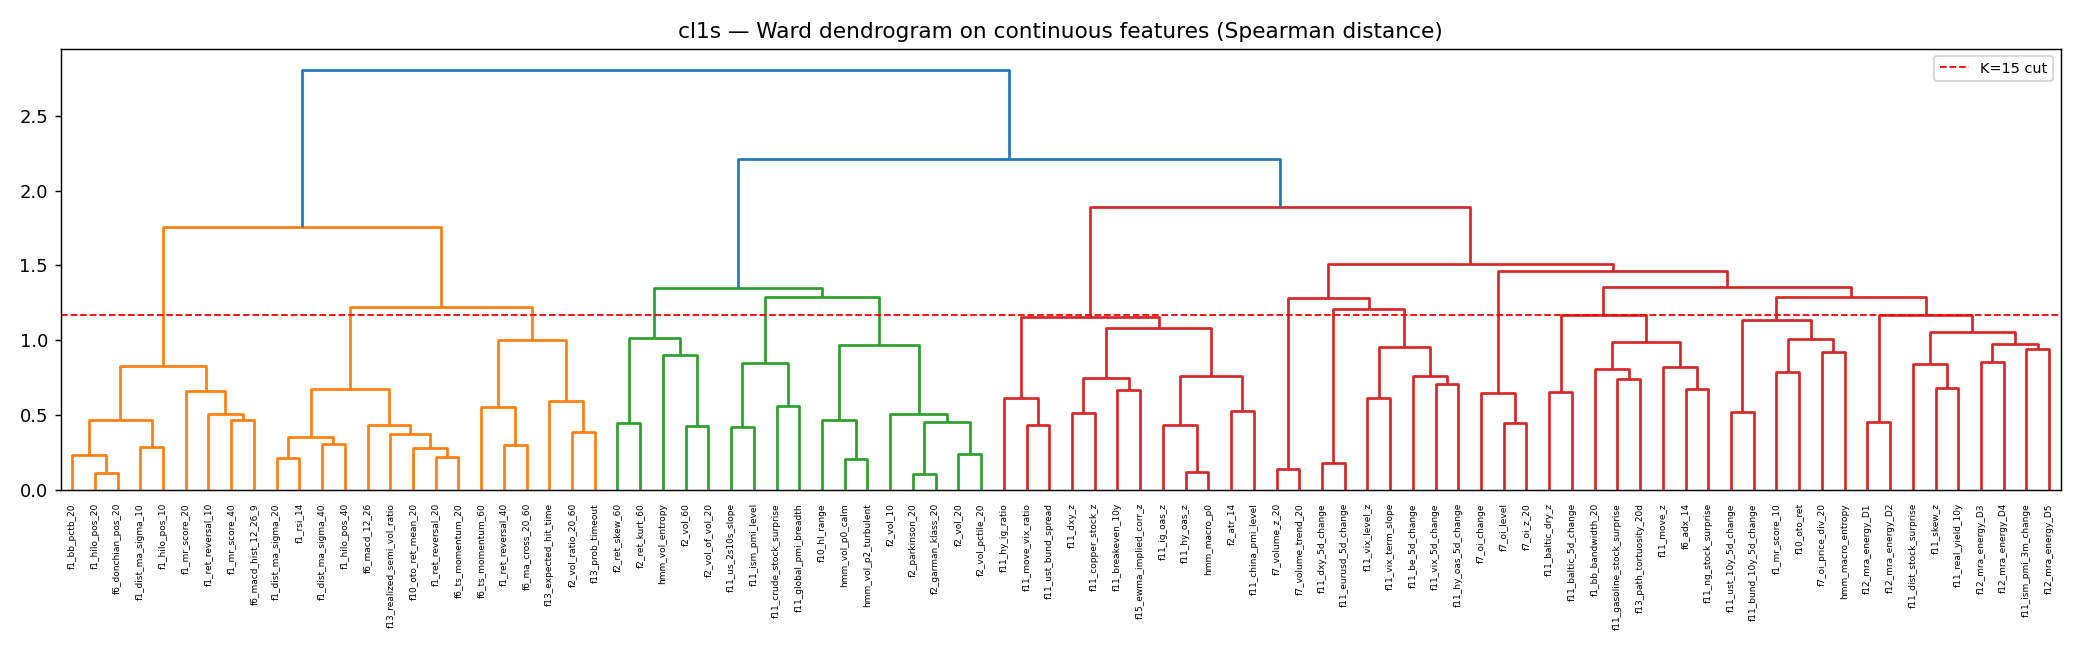

In [3]:
show(BASE / "cl1s" / "dendrogram.png", width=1100)


### 2 · Cluster-level importance

**Clustered MDA** (centerpiece): dark bars = significant (mean > 1σ from zero),
light = inconclusive. Error bars = ± std across CPCV paths.

**Cross-checks:** MDI sums `feature_importances_` per cluster (train-set, upward-biased).
Group SHAP sums mean|SHAP| per cluster (OOS, `tree_path_dependent`).
Kendall τ between cluster rankings flags whether the three methods agree.
MDI and SHAP typically agree strongly (intrinsic statistics); MDA is noisier (OOS test).


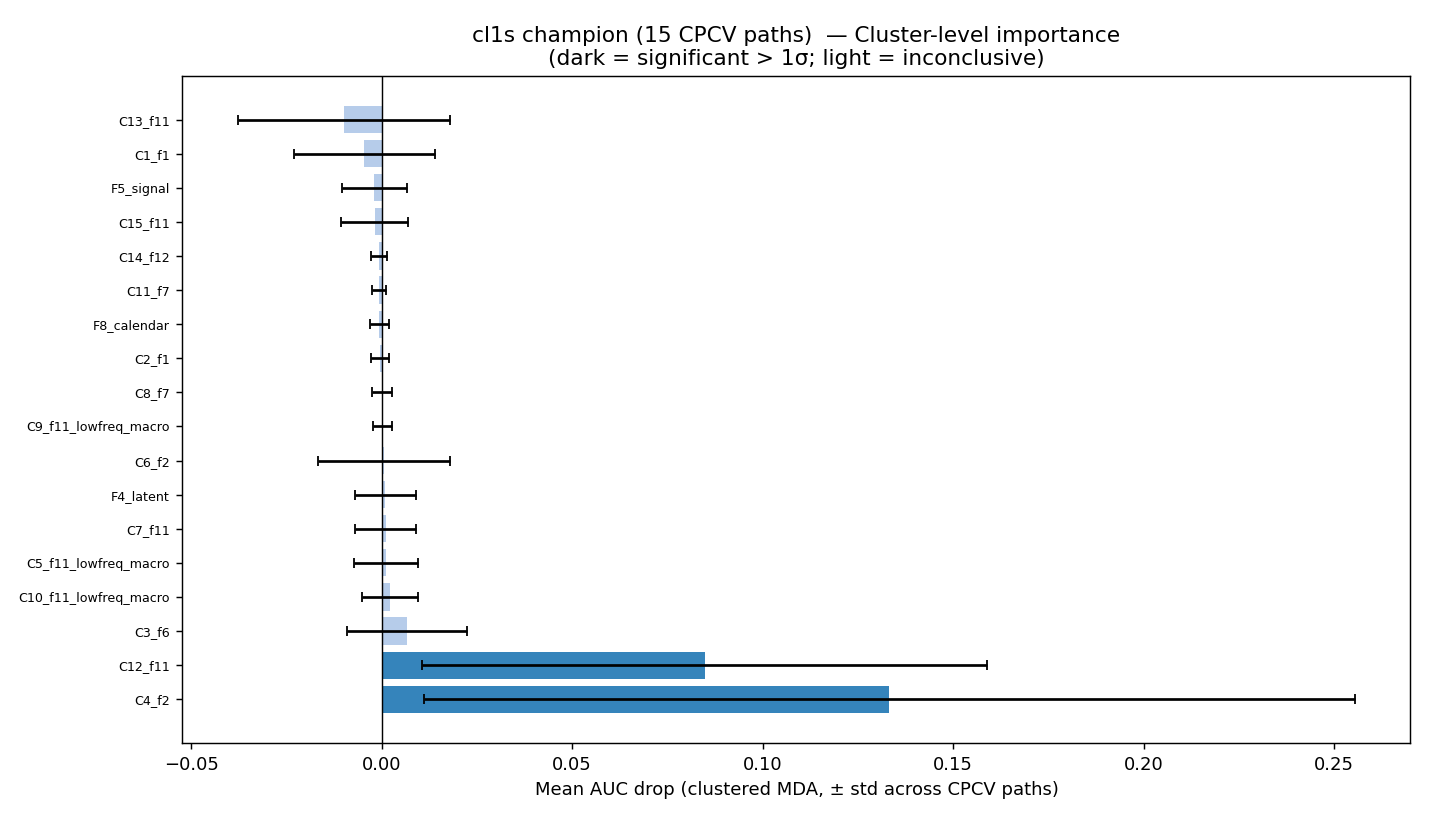

In [4]:
show(BASE / "cl1s" / "clustered_mda_chart.png", width=1050)


In [5]:
cc = load(BASE / "cl1s" / "cluster_crosscheck_table.csv")
ra = load(BASE / "cl1s" / "rank_agreement.csv")
if not cc.empty:
    display(
        cc.style
        .format({"mda_mean": "{:.4f}", "mdi_sum": "{:.4f}", "shap_sum": "{:.4f}"})
        .background_gradient(subset=["mda_mean"], cmap="RdYlGn", vmin=-0.05, vmax=0.15)
        .set_caption("cl1s — cluster cross-check table (MDA · MDI · SHAP ranks)")
    )
if not ra.empty:
    print("\nKendall τ rank agreement:")
    display(ra.style.format({"kendall_tau": "{:.2f}"}))


,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,C4_f2,0.1332,1,0.2128,1,0.6040,1,True
1,C12_f11,0.0848,2,0.2006,2,0.4575,2,True
2,C3_f6,0.0066,3,0.0497,7,0.0361,9,False
3,C10_f11_lowfreq_macro,0.0022,4,0.0308,10,0.0769,7,False
4,C5_f11_lowfreq_macro,0.0012,5,0.0327,9,0.0303,11,False
5,C7_f11,0.0011,6,0.1160,3,0.0863,4,False
6,F4_latent,0.0010,7,0.0390,8,0.0304,10,False
7,C6_f2,0.0006,8,0.0757,4,0.0821,6,False
8,C9_f11_lowfreq_macro,0.0002,9,0.0106,15,0.0122,14,False
9,C8_f7,0.0002,10,0.0052,18,0.0054,18,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.35,False
1,MDA-SHAP,0.25,False
2,MDI-SHAP,0.80,True


### 3 · Within-cluster breakdown (top clusters)

Members ranked by mean|SHAP|. Single-feature permutation is not used within a cluster
because correlated siblings underestimate importance — only the cluster-total MDA is
reliable. PCA checks whether the cluster is one latent dimension (high PC1 variance)
and which feature anchors it (PC1 loadings).


,feature,mean_shap_mag,pc1_loading
0,f2_vol_60,0.5183,0.507
1,hmm_vol_entropy,0.0358,-0.225
2,f2_ret_kurt_60,0.0252,0.504
3,f2_vol_of_vol_20,0.0225,0.489
4,f2_ret_skew_60,0.0022,-0.446


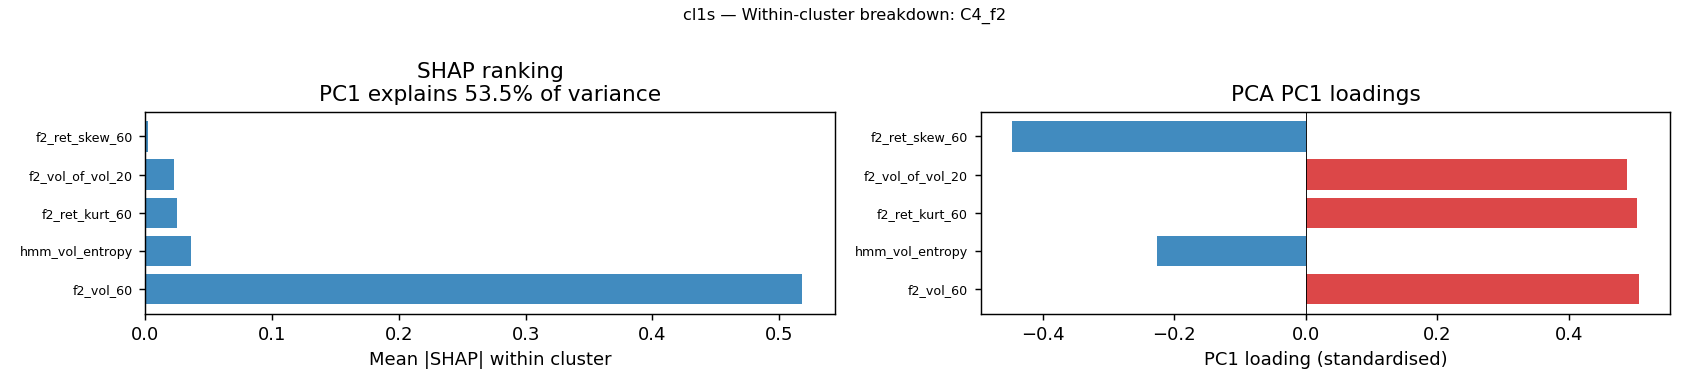

In [6]:
wc = load(BASE / "cl1s" / "within_cluster_C4_f2.csv")
if not wc.empty:
    pc1 = wc["pca_pc1_var_explained"].iloc[0]
    label = f"PC1 explains {pc1:.1%}" if pd.notna(pc1) else "PCA n/a"
    display(
        wc[["feature", "mean_shap_mag", "pc1_loading"]]
        .style
        .format({"mean_shap_mag": "{:.4f}", "pc1_loading": "{:.3f}"})
        .background_gradient(subset=["mean_shap_mag"], cmap="Blues")
        .set_caption(f"cl1s | C4_f2 — SHAP ranking + PC1 loadings  ({label})")
    )
show(BASE / "cl1s" / "within_cluster_C4_f2.png", width=1050)


,feature,mean_shap_mag,pc1_loading
0,f11_move_z,0.2738,-0.310
1,f11_gasoline_stock_surprise,0.0680,-0.326
2,f1_bb_bandwidth_20,0.0506,-0.221
3,f11_baltic_dry_z,0.0260,0.430
4,f6_adx_14,0.0170,-0.469
5,f11_baltic_5d_change,0.0097,0.234
6,f13_path_tortuosity_20d,0.0076,0.035
7,f11_ng_stock_surprise,0.0047,0.537


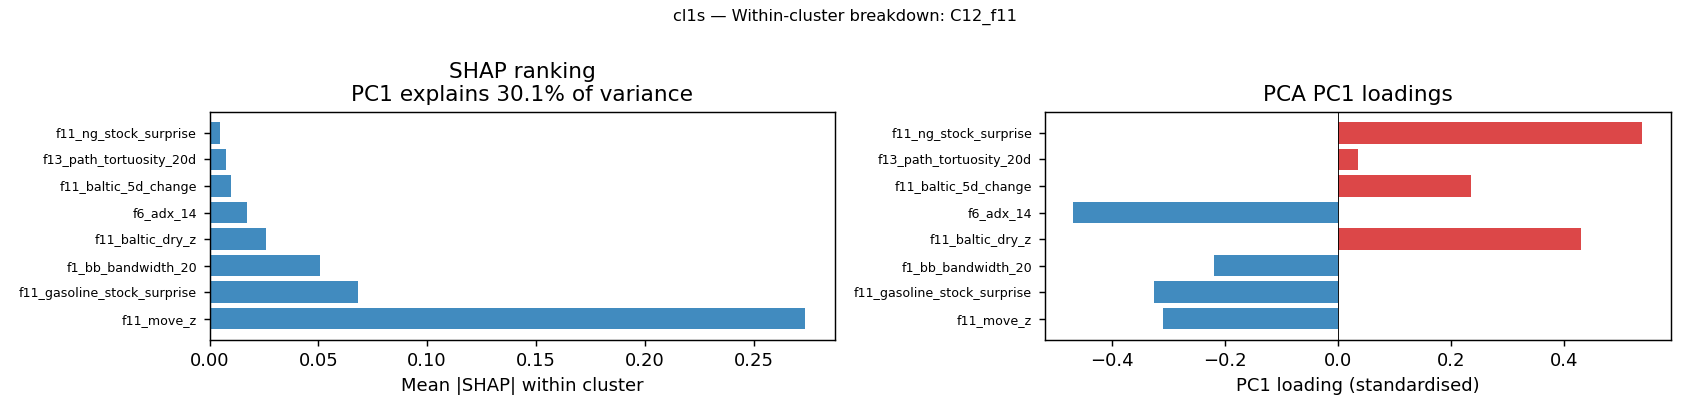

In [7]:
wc = load(BASE / "cl1s" / "within_cluster_C12_f11.csv")
if not wc.empty:
    pc1 = wc["pca_pc1_var_explained"].iloc[0]
    label = f"PC1 explains {pc1:.1%}" if pd.notna(pc1) else "PCA n/a"
    display(
        wc[["feature", "mean_shap_mag", "pc1_loading"]]
        .style
        .format({"mean_shap_mag": "{:.4f}", "pc1_loading": "{:.3f}"})
        .background_gradient(subset=["mean_shap_mag"], cmap="Blues")
        .set_caption(f"cl1s | C12_f11 — SHAP ranking + PC1 loadings  ({label})")
    )
show(BASE / "cl1s" / "within_cluster_C12_f11.png", width=1050)


,feature,mean_shap_mag,pc1_loading
0,f13_prob_timeout,0.0142,0.448
1,f6_ts_momentum_60,0.0077,-0.351
2,f13_expected_hit_time,0.0068,0.375
3,f1_ret_reversal_40,0.0026,0.416
4,f6_ma_cross_20_60,0.0025,-0.437
5,f2_vol_ratio_20_60,0.0023,0.415


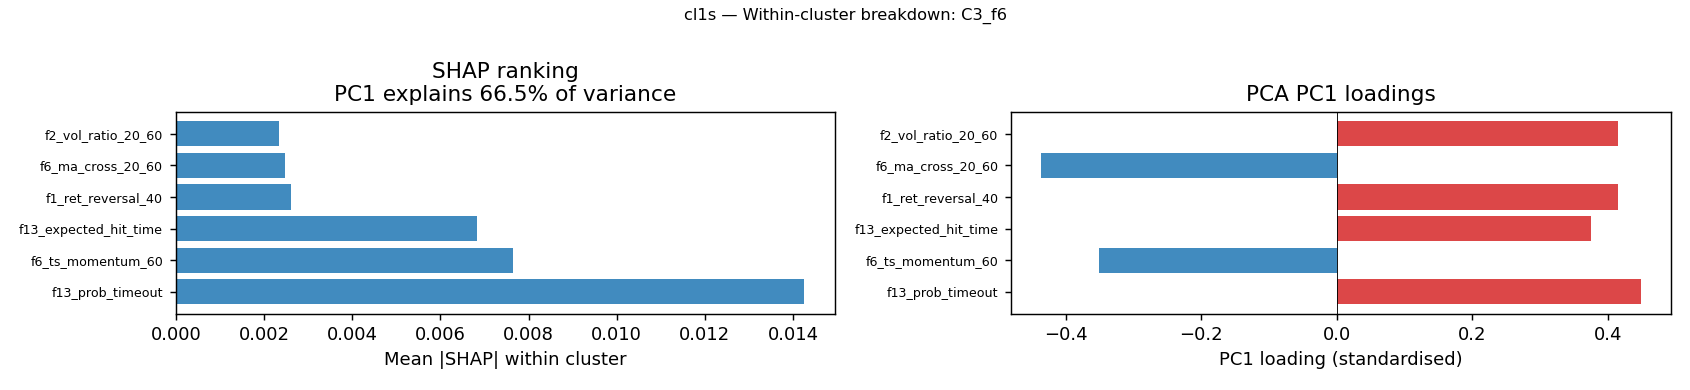

In [8]:
wc = load(BASE / "cl1s" / "within_cluster_C3_f6.csv")
if not wc.empty:
    pc1 = wc["pca_pc1_var_explained"].iloc[0]
    label = f"PC1 explains {pc1:.1%}" if pd.notna(pc1) else "PCA n/a"
    display(
        wc[["feature", "mean_shap_mag", "pc1_loading"]]
        .style
        .format({"mean_shap_mag": "{:.4f}", "pc1_loading": "{:.3f}"})
        .background_gradient(subset=["mean_shap_mag"], cmap="Blues")
        .set_caption(f"cl1s | C3_f6 — SHAP ranking + PC1 loadings  ({label})")
    )
show(BASE / "cl1s" / "within_cluster_C3_f6.png", width=1050)


### 4 · Global per-feature SHAP + MDI

Mean|SHAP| and signed SHAP per feature, averaged across CPCV paths on the target
instrument's test slice. MDI is the fold-averaged `feature_importances_` (sanity check).
Correlated siblings read low here individually — compare with the cluster-total MDA
above to see the correlation problem directly.


,feature,shap_magnitude,shap_signed,mdi
0,f2_vol_60,0.5183,0.2277,0.1435
1,f11_move_z,0.2738,-0.0334,0.0667
2,f11_gasoline_stock_surprise,0.0680,0.0152,0.0383
3,f11_vix_term_slope,0.0551,0.0306,0.0153
4,f1_bb_bandwidth_20,0.0506,0.0197,0.0334
5,f11_real_yield_10y,0.0412,0.0261,0.0230
6,hmm_vol_entropy,0.0358,0.0091,0.0069
7,f2_vol_20,0.0344,0.0139,0.0162
8,f12_mra_energy_D3,0.0265,0.0121,0.0090
9,f11_baltic_dry_z,0.0260,0.0017,0.0167


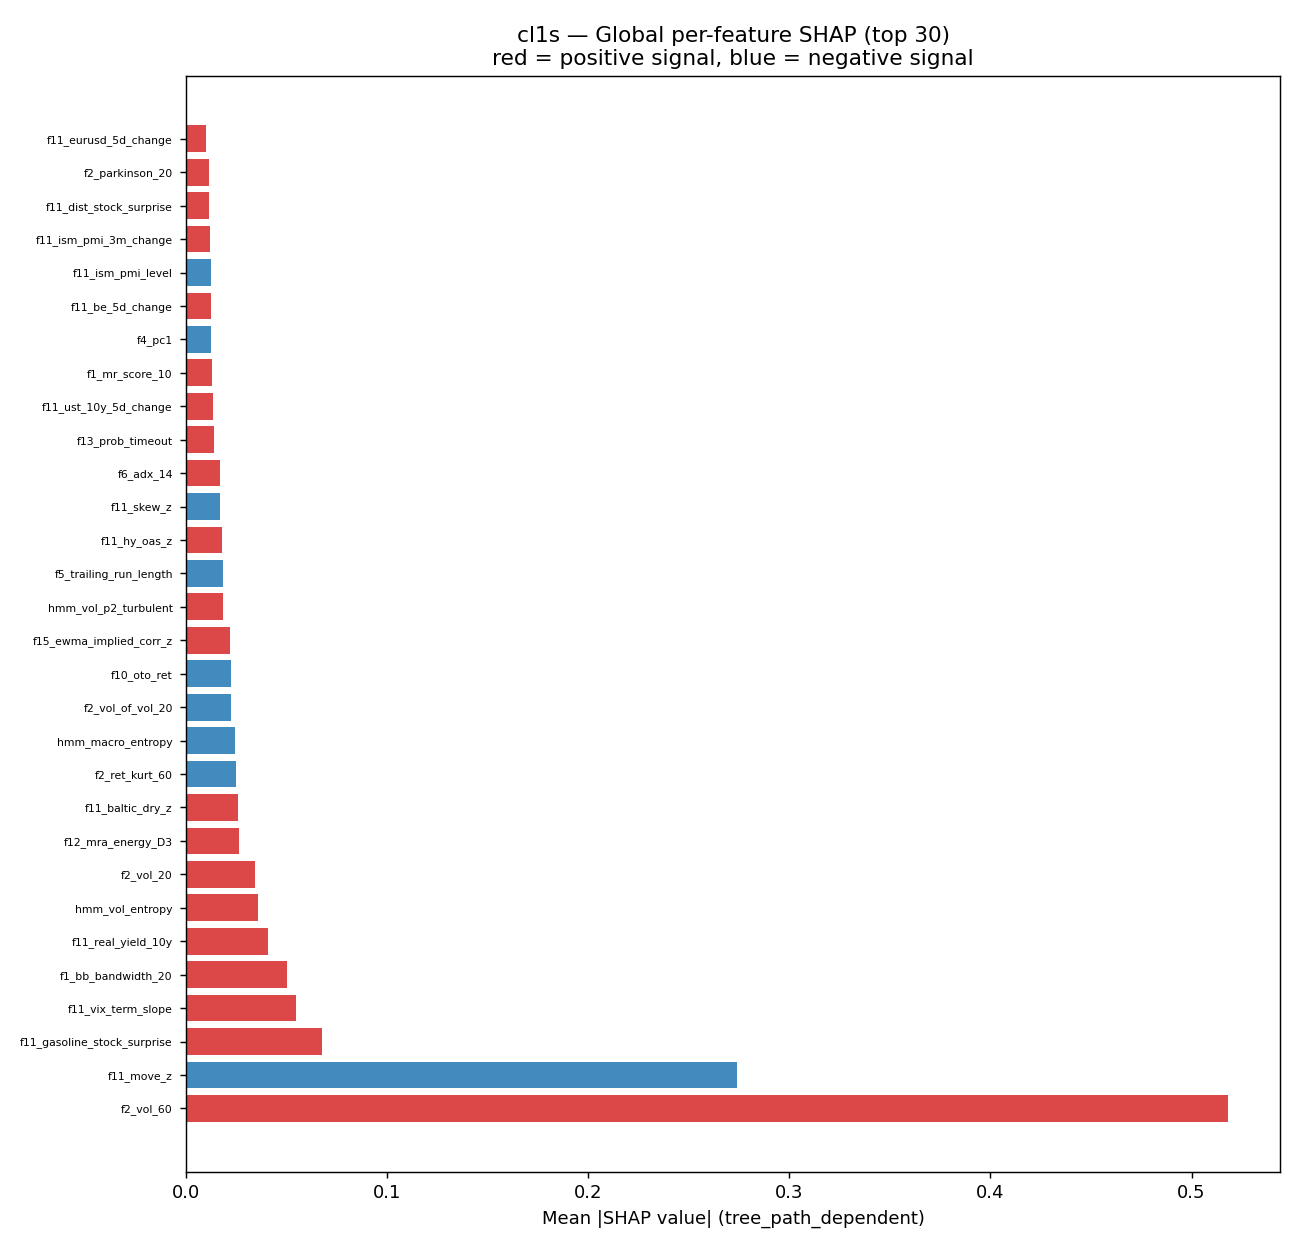

In [9]:
gs = load(BASE / "cl1s" / "global_shap_summary.csv")
if not gs.empty:
    display(
        gs.head(25).style
        .format({"shap_magnitude": "{:.4f}", "shap_signed": "{:.4f}", "mdi": "{:.4f}"})
        .background_gradient(subset=["shap_magnitude"], cmap="Blues")
        .set_caption("cl1s — top 25 features by mean|SHAP| (red=positive, blue=negative signal)")
    )
show(BASE / "cl1s" / "global_shap_chart.png", width=1000)


---
## ES1S — champion: `es1s` / RF

**CPCV:** 15 paths · AUC 0.605±0.069 · signal: *marginal*  
**Significant clusters (mean > 1σ):** `F5_signal`

S&P 500 E-mini, individual model. Marginal signal (lower CI just clears 0.5). Only the signal-derived cluster (F5) clears the 1σ bar; all other clusters are inconclusive. Rankings carry large path uncertainty.


### 1 · Feature clusters

Features split into a **correlation-cluster block** (Ward linkage on √(1−|ρ|) Spearman
distance, K by silhouette) plus hand-assigned groups (F4 latent PCA, F5 signal-derived,
F8 calendar; F_instrument dummies for pooled models). Near-perfect pairs (|ρ| ≥ 0.99)
are deduplicated before clustering.

*Purity* = fraction of cluster members from the dominant F-prefix.
≥ 80% = the data-driven cluster recovered a semantic F-group.


In [10]:
# Cluster membership summary — es1s
cs = cluster_summary("es1s")
display(
    cs.style
    .format({"mean_drop": "{:.4f}", "std_drop": "{:.4f}", "purity": "{:.0%}"})
    .background_gradient(subset=["mean_drop"], cmap="RdYlGn", vmin=-0.05, vmax=0.15)
    .set_caption("es1s — cluster summary (sorted by mean MDA drop)")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-weight","bold"),("font-size","12px")]}])
)


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
13,F5_signal,5,f5_,100%,0.0752,0.0374,True
10,C8_f11,9,f11_,67%,0.0179,0.0301,False
4,C2_f11,6,f11_,67%,0.0125,0.0245,False
11,C9_f11,8,f11_,50%,0.0082,0.0247,False
6,C4_f2,13,f2_,54%,0.0075,0.0161,False
7,C5_f11_lowfreq_macro,2,f11_,100%,0.0027,0.0066,False
9,C7_f11_lowfreq_macro,2,f11_,100%,0.0011,0.0021,False
8,C6_f7,7,f7_,29%,0.0002,0.0068,False
14,F8_calendar,4,f8_,100%,-0.0006,0.0061,False
12,F4_latent,4,f4_,100%,-0.0018,0.0059,False


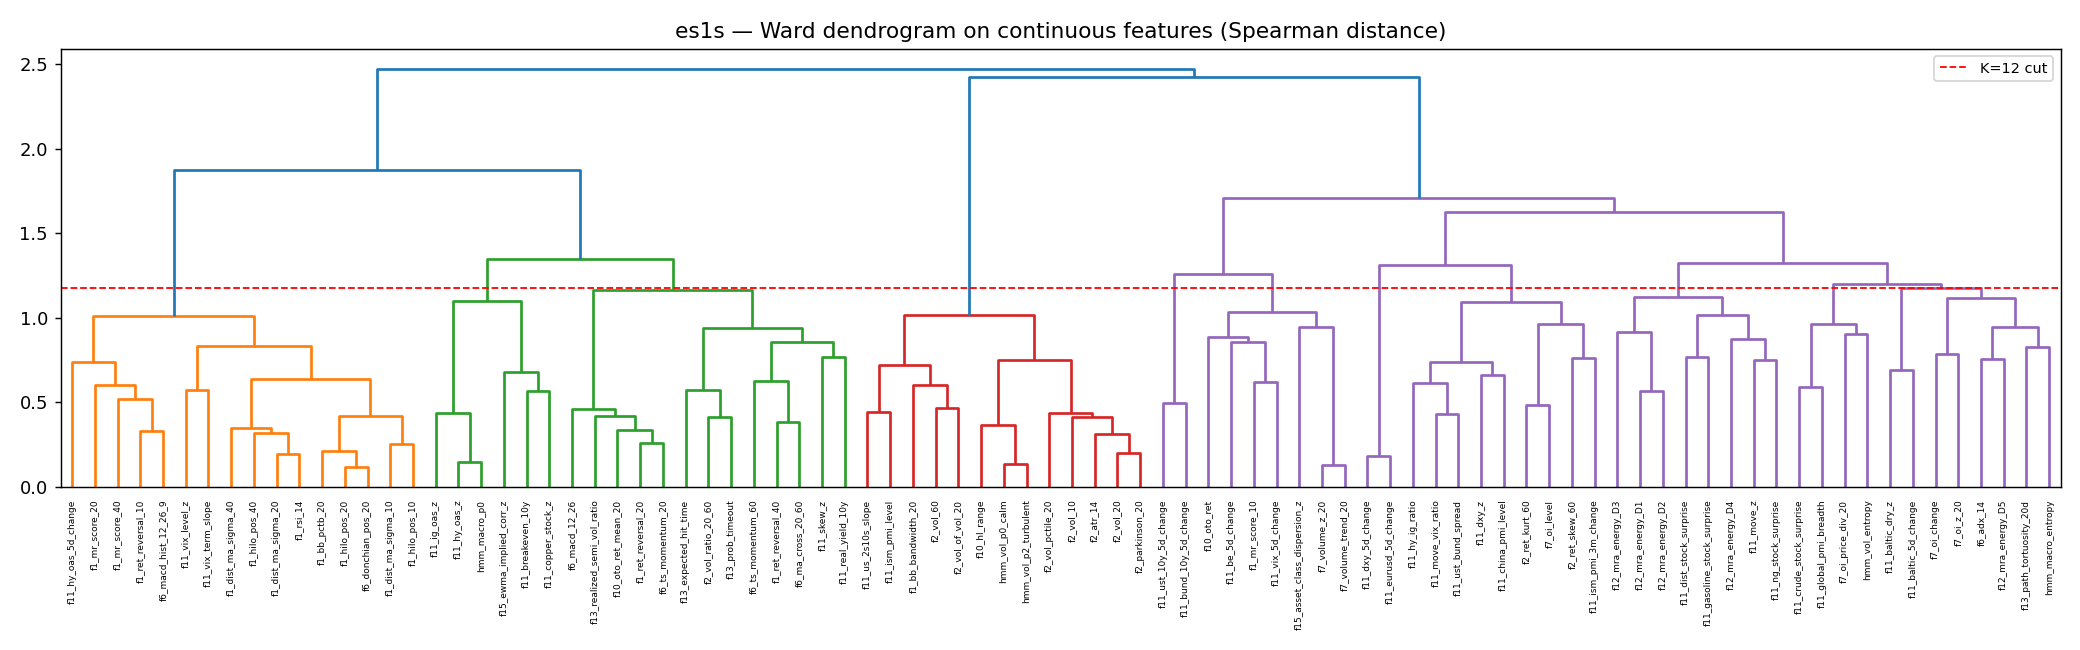

In [11]:
show(BASE / "es1s" / "dendrogram.png", width=1100)


### 2 · Cluster-level importance

**Clustered MDA** (centerpiece): dark bars = significant (mean > 1σ from zero),
light = inconclusive. Error bars = ± std across CPCV paths.

**Cross-checks:** MDI sums `feature_importances_` per cluster (train-set, upward-biased).
Group SHAP sums mean|SHAP| per cluster (OOS, `tree_path_dependent`).
Kendall τ between cluster rankings flags whether the three methods agree.
MDI and SHAP typically agree strongly (intrinsic statistics); MDA is noisier (OOS test).


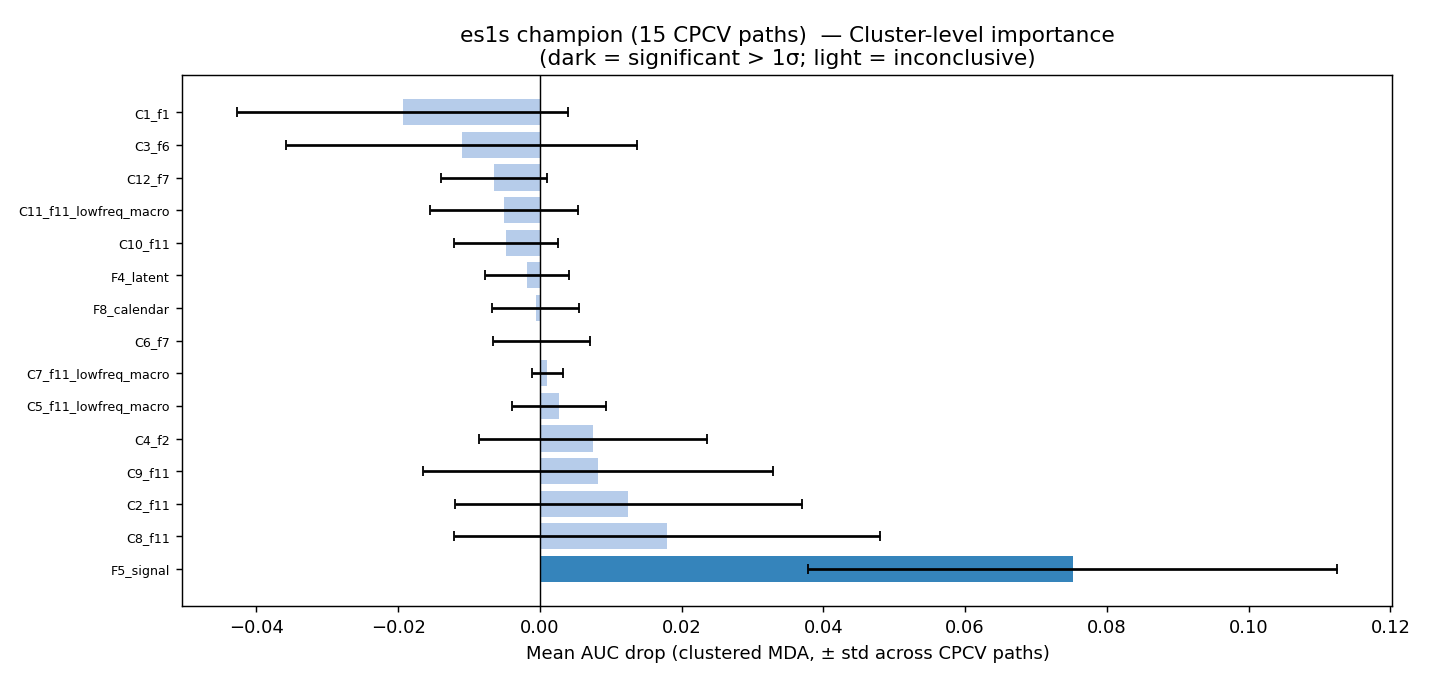

In [12]:
show(BASE / "es1s" / "clustered_mda_chart.png", width=1050)


In [13]:
cc = load(BASE / "es1s" / "cluster_crosscheck_table.csv")
ra = load(BASE / "es1s" / "rank_agreement.csv")
if not cc.empty:
    display(
        cc.style
        .format({"mda_mean": "{:.4f}", "mdi_sum": "{:.4f}", "shap_sum": "{:.4f}"})
        .background_gradient(subset=["mda_mean"], cmap="RdYlGn", vmin=-0.05, vmax=0.15)
        .set_caption("es1s — cluster cross-check table (MDA · MDI · SHAP ranks)")
    )
if not ra.empty:
    print("\nKendall τ rank agreement:")
    display(ra.style.format({"kendall_tau": "{:.2f}"}))


,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,F5_signal,0.0752,1,0.1395,2,0.0487,2,True
1,C8_f11,0.0179,2,0.1522,1,0.0494,1,False
2,C2_f11,0.0125,3,0.0683,7,0.0169,7,False
3,C9_f11,0.0082,4,0.1128,5,0.0314,4,False
4,C4_f2,0.0075,5,0.1288,3,0.0397,3,False
5,C5_f11_lowfreq_macro,0.0027,6,0.0157,13,0.0044,13,False
6,C7_f11_lowfreq_macro,0.0011,7,0.0110,14,0.0032,15,False
7,C6_f7,0.0002,8,0.0390,9,0.0096,9,False
8,F8_calendar,-0.0006,9,0.0089,15,0.0034,14,False
9,F4_latent,-0.0018,10,0.0284,10,0.0067,11,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.20,False
1,MDA-SHAP,0.18,False
2,MDI-SHAP,0.94,True


### 3 · Within-cluster breakdown (top clusters)

Members ranked by mean|SHAP|. Single-feature permutation is not used within a cluster
because correlated siblings underestimate importance — only the cluster-total MDA is
reliable. PCA checks whether the cluster is one latent dimension (high PC1 variance)
and which feature anchors it (PC1 loadings).


,feature,mean_shap_mag,pc1_loading
0,f5_trailing_run_length,0.0342,0.499
1,f5_long_bias_20,0.0083,0.544
2,f5_signal,0.0031,0.382
3,f5_participation_20,0.0020,0.482
4,f5_sign_agree_mr,0.0011,-0.278


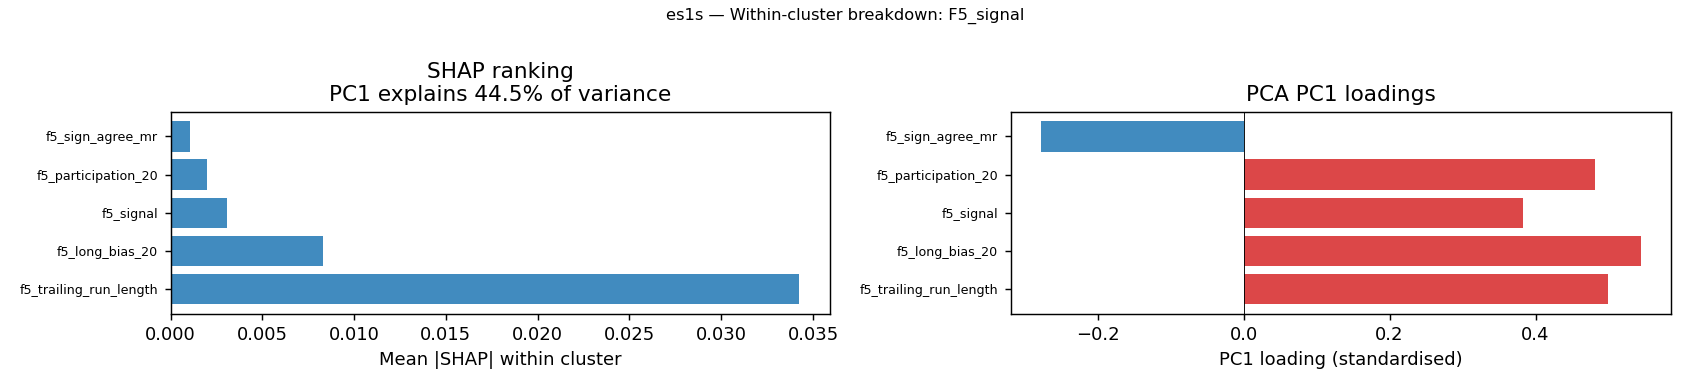

In [14]:
wc = load(BASE / "es1s" / "within_cluster_F5_signal.csv")
if not wc.empty:
    pc1 = wc["pca_pc1_var_explained"].iloc[0]
    label = f"PC1 explains {pc1:.1%}" if pd.notna(pc1) else "PCA n/a"
    display(
        wc[["feature", "mean_shap_mag", "pc1_loading"]]
        .style
        .format({"mean_shap_mag": "{:.4f}", "pc1_loading": "{:.3f}"})
        .background_gradient(subset=["mean_shap_mag"], cmap="Blues")
        .set_caption(f"es1s | F5_signal — SHAP ranking + PC1 loadings  ({label})")
    )
show(BASE / "es1s" / "within_cluster_F5_signal.png", width=1050)


,feature,mean_shap_mag,pc1_loading
0,f11_hy_ig_ratio,0.0104,0.427
1,f11_move_vix_ratio,0.0081,-0.417
2,f11_ust_bund_spread,0.0065,-0.408
3,f7_oi_level,0.0059,0.289
4,f11_ism_pmi_3m_change,0.0048,0.145
5,f11_china_pmi_level,0.0039,0.014
6,f2_ret_kurt_60,0.0038,0.380
7,f11_dxy_z,0.0033,-0.335
8,f2_ret_skew_60,0.0026,-0.340


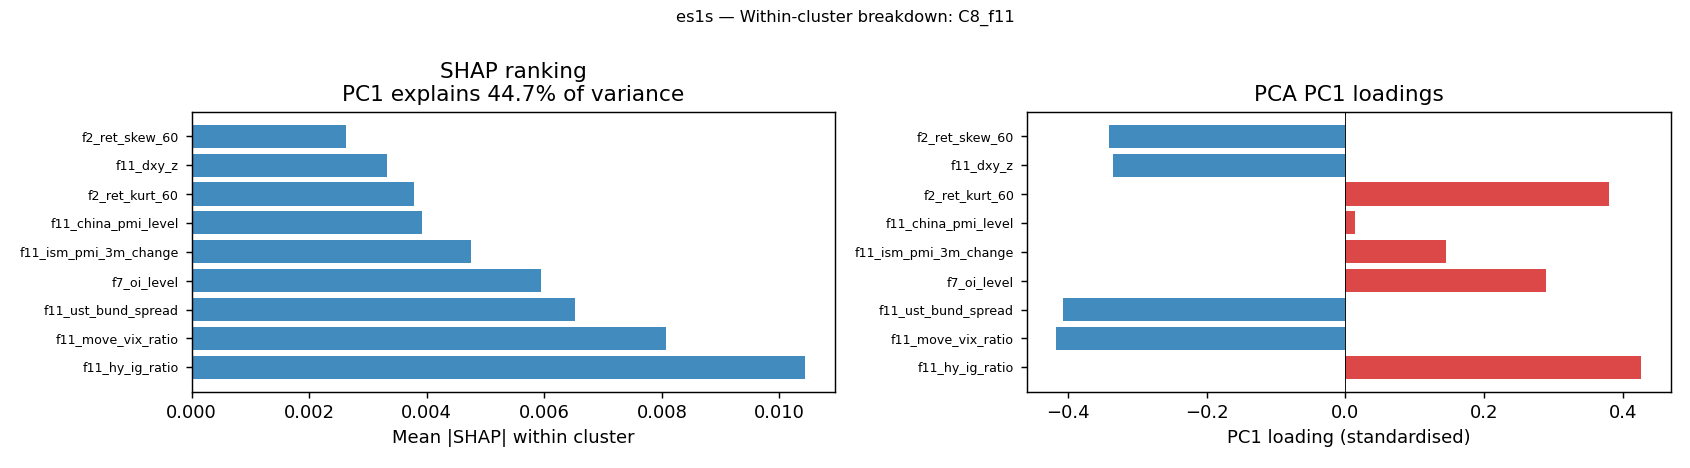

In [15]:
wc = load(BASE / "es1s" / "within_cluster_C8_f11.csv")
if not wc.empty:
    pc1 = wc["pca_pc1_var_explained"].iloc[0]
    label = f"PC1 explains {pc1:.1%}" if pd.notna(pc1) else "PCA n/a"
    display(
        wc[["feature", "mean_shap_mag", "pc1_loading"]]
        .style
        .format({"mean_shap_mag": "{:.4f}", "pc1_loading": "{:.3f}"})
        .background_gradient(subset=["mean_shap_mag"], cmap="Blues")
        .set_caption(f"es1s | C8_f11 — SHAP ranking + PC1 loadings  ({label})")
    )
show(BASE / "es1s" / "within_cluster_C8_f11.png", width=1050)


,feature,mean_shap_mag,pc1_loading
0,f11_breakeven_10y,0.0069,-0.390
1,f11_copper_stock_z,0.0028,-0.403
2,f11_ig_oas_z,0.0024,0.425
3,f15_ewma_implied_corr_z,0.0023,0.348
4,hmm_macro_p0,0.0016,-0.426
5,f11_hy_oas_z,0.0009,0.450


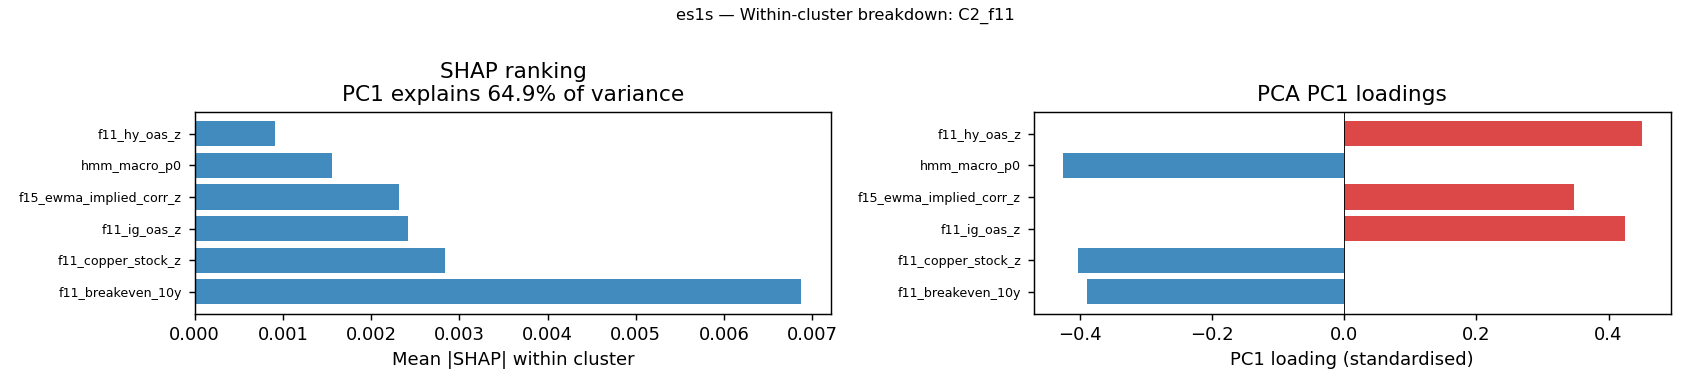

In [16]:
wc = load(BASE / "es1s" / "within_cluster_C2_f11.csv")
if not wc.empty:
    pc1 = wc["pca_pc1_var_explained"].iloc[0]
    label = f"PC1 explains {pc1:.1%}" if pd.notna(pc1) else "PCA n/a"
    display(
        wc[["feature", "mean_shap_mag", "pc1_loading"]]
        .style
        .format({"mean_shap_mag": "{:.4f}", "pc1_loading": "{:.3f}"})
        .background_gradient(subset=["mean_shap_mag"], cmap="Blues")
        .set_caption(f"es1s | C2_f11 — SHAP ranking + PC1 loadings  ({label})")
    )
show(BASE / "es1s" / "within_cluster_C2_f11.png", width=1050)


### 4 · Global per-feature SHAP + MDI

Mean|SHAP| and signed SHAP per feature, averaged across CPCV paths on the target
instrument's test slice. MDI is the fold-averaged `feature_importances_` (sanity check).
Correlated siblings read low here individually — compare with the cluster-total MDA
above to see the correlation problem directly.


,feature,shap_magnitude,shap_signed,mdi
0,f5_trailing_run_length,0.0342,0.0038,0.0976
1,f11_hy_ig_ratio,0.0104,0.0015,0.0296
2,f5_long_bias_20,0.0083,0.0011,0.0242
3,f11_move_vix_ratio,0.0081,-0.0004,0.0214
4,f11_move_z,0.0070,-0.0004,0.0232
5,f11_breakeven_10y,0.0069,0.0005,0.0280
6,f11_dist_stock_surprise,0.0069,0.0007,0.0248
7,f11_ust_bund_spread,0.0065,0.0009,0.0187
8,f11_baltic_dry_z,0.0062,0.0013,0.0195
9,f7_oi_level,0.0059,0.0018,0.0186


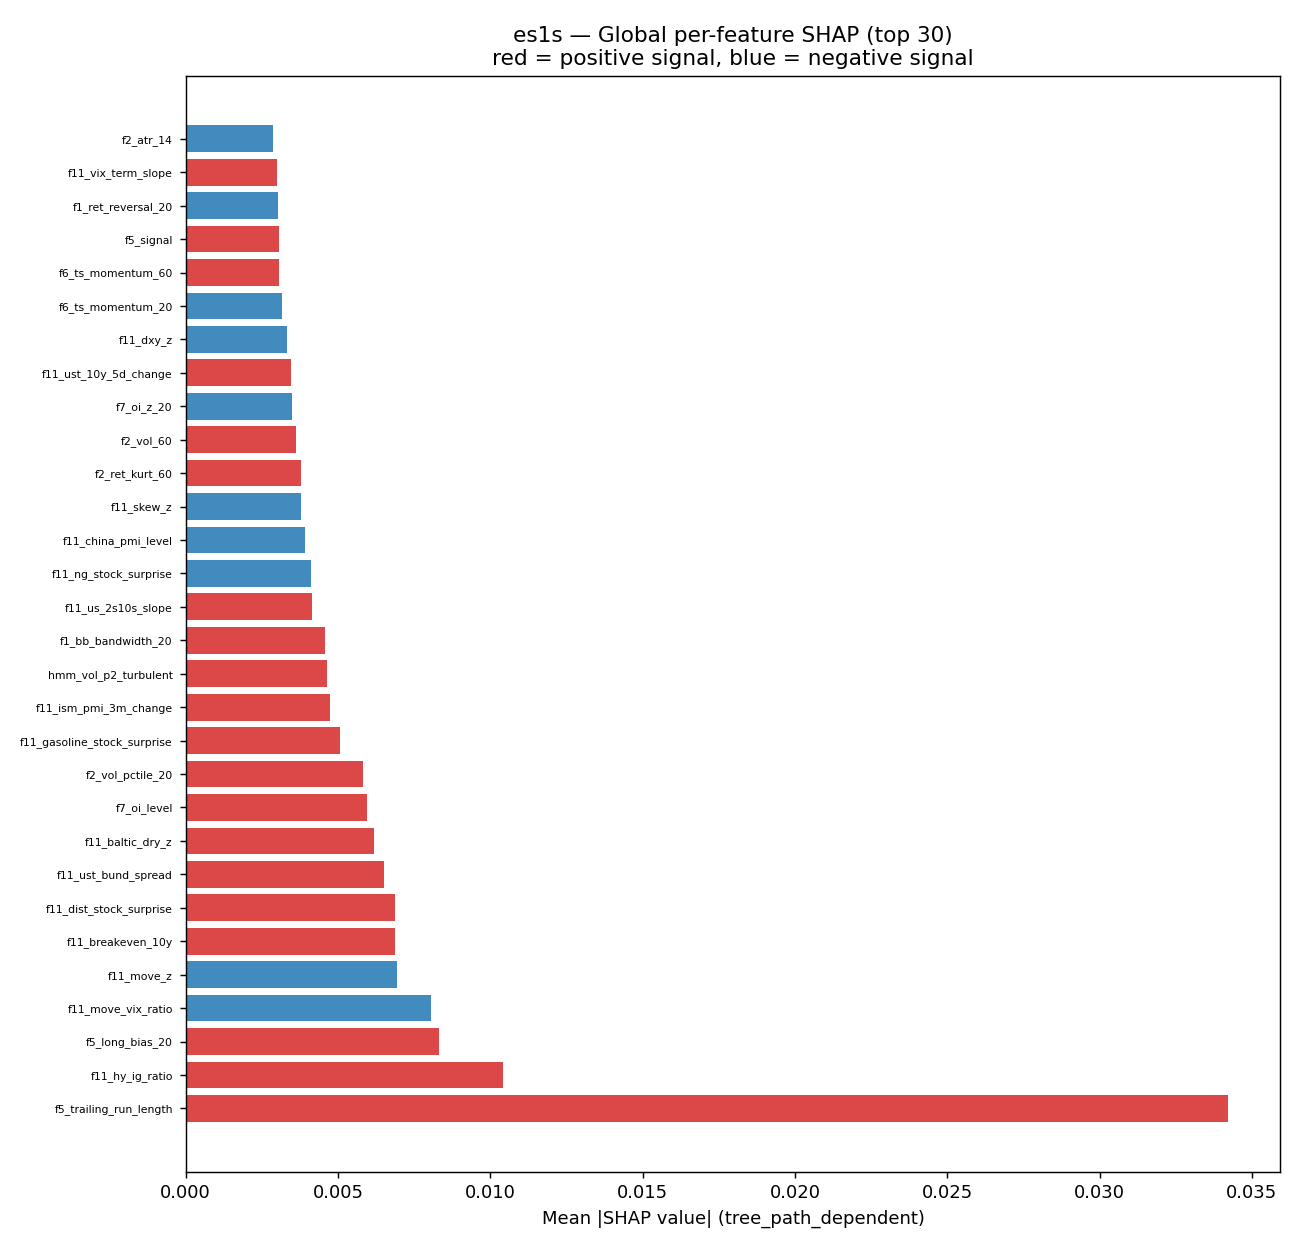

In [17]:
gs = load(BASE / "es1s" / "global_shap_summary.csv")
if not gs.empty:
    display(
        gs.head(25).style
        .format({"shap_magnitude": "{:.4f}", "shap_signed": "{:.4f}", "mdi": "{:.4f}"})
        .background_gradient(subset=["shap_magnitude"], cmap="Blues")
        .set_caption("es1s — top 25 features by mean|SHAP| (red=positive, blue=negative signal)")
    )
show(BASE / "es1s" / "global_shap_chart.png", width=1000)


---
## HO1S — champion: `energy_cl_ho` / RF

**CPCV:** 15 paths · AUC 0.634±0.227 · signal: *strong/noisy*  
**Significant clusters (mean > 1σ):** none — all within 1σ of zero

Heating oil, scored from the `energy_cl_ho` pooled RF on ho1s's test slice. Strong mean AUC but high path std (0.227); thin event set with single-class folds dropped. **No cluster clears the 1σ threshold** — treat as indicative.


### 1 · Feature clusters

Features split into a **correlation-cluster block** (Ward linkage on √(1−|ρ|) Spearman
distance, K by silhouette) plus hand-assigned groups (F4 latent PCA, F5 signal-derived,
F8 calendar; F_instrument dummies for pooled models). Near-perfect pairs (|ρ| ≥ 0.99)
are deduplicated before clustering.

*Purity* = fraction of cluster members from the dominant F-prefix.
≥ 80% = the data-driven cluster recovered a semantic F-group.


In [18]:
# Cluster membership summary — ho1s
cs = cluster_summary("ho1s")
display(
    cs.style
    .format({"mean_drop": "{:.4f}", "std_drop": "{:.4f}", "purity": "{:.0%}"})
    .background_gradient(subset=["mean_drop"], cmap="RdYlGn", vmin=-0.05, vmax=0.15)
    .set_caption("ho1s — cluster summary (sorted by mean MDA drop)")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-weight","bold"),("font-size","12px")]}])
)


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
3,C13_f11,10,f11_,50%,0.0662,0.2475,False
13,F4_latent,4,f4_,100%,0.0230,0.0869,False
0,C10_f11_lowfreq_macro,7,f11_,100%,0.0215,0.0773,False
14,F5_signal,5,f5_,100%,0.0214,0.0373,False
2,C12_f12,9,f12_,56%,0.0205,0.0968,False
9,C6_f11_lowfreq_macro,5,f11_,100%,0.0179,0.0586,False
7,C4_f2,8,f2_,62%,0.0109,0.1024,False
15,F8_calendar,4,f8_,100%,0.0095,0.0213,False
5,C2_f1,15,f1_,40%,0.0055,0.0734,False
1,C11_f7,3,f7_,100%,0.0033,0.0188,False


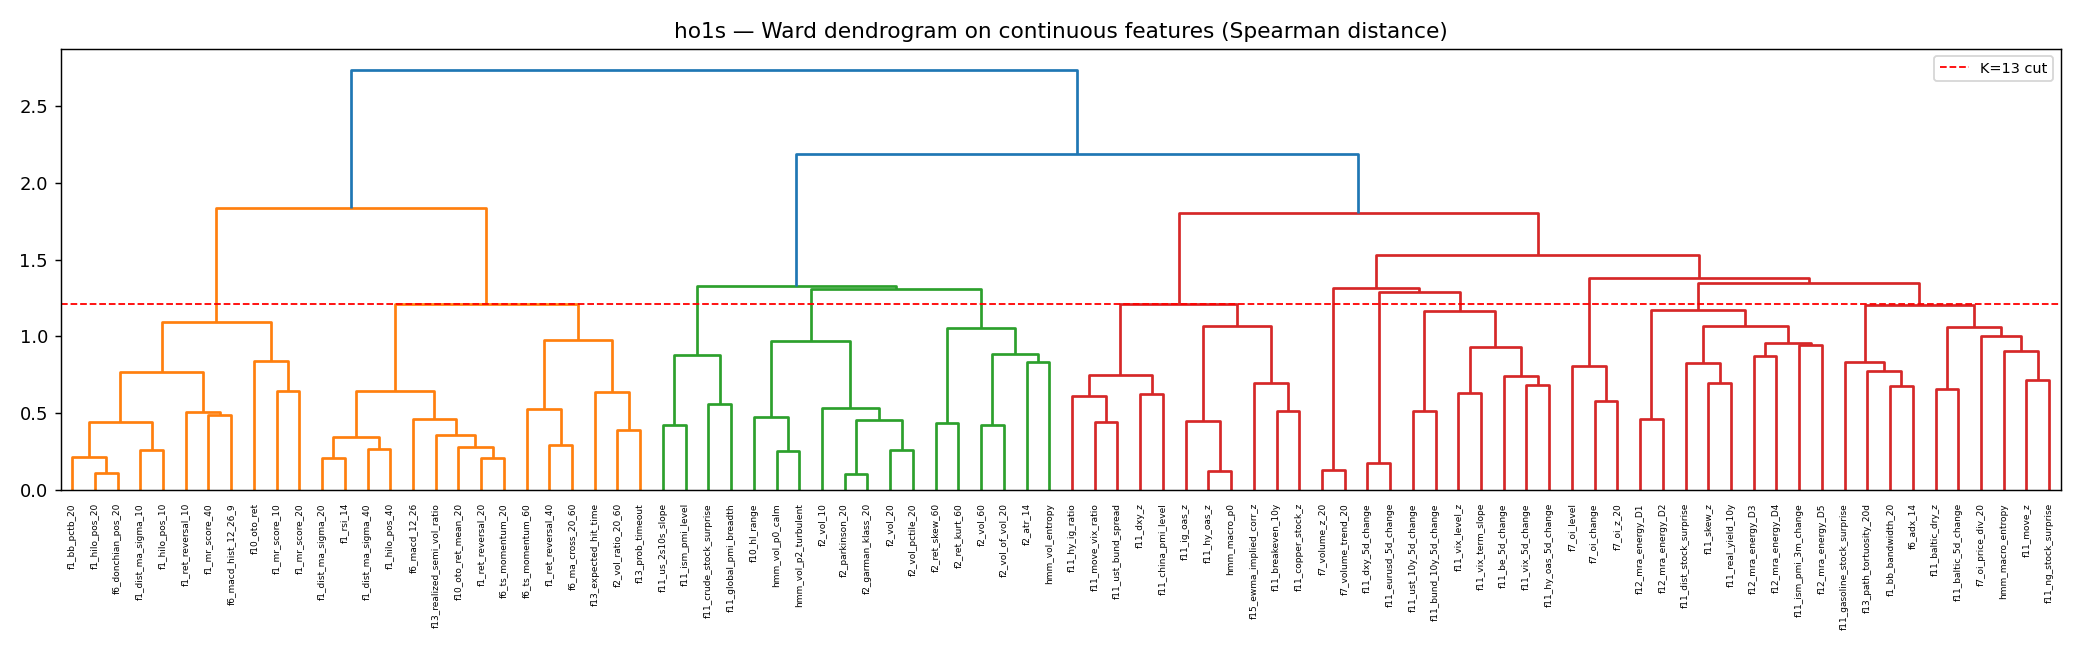

In [19]:
show(BASE / "ho1s" / "dendrogram.png", width=1100)


### 2 · Cluster-level importance

**Clustered MDA** (centerpiece): dark bars = significant (mean > 1σ from zero),
light = inconclusive. Error bars = ± std across CPCV paths.

**Cross-checks:** MDI sums `feature_importances_` per cluster (train-set, upward-biased).
Group SHAP sums mean|SHAP| per cluster (OOS, `tree_path_dependent`).
Kendall τ between cluster rankings flags whether the three methods agree.
MDI and SHAP typically agree strongly (intrinsic statistics); MDA is noisier (OOS test).


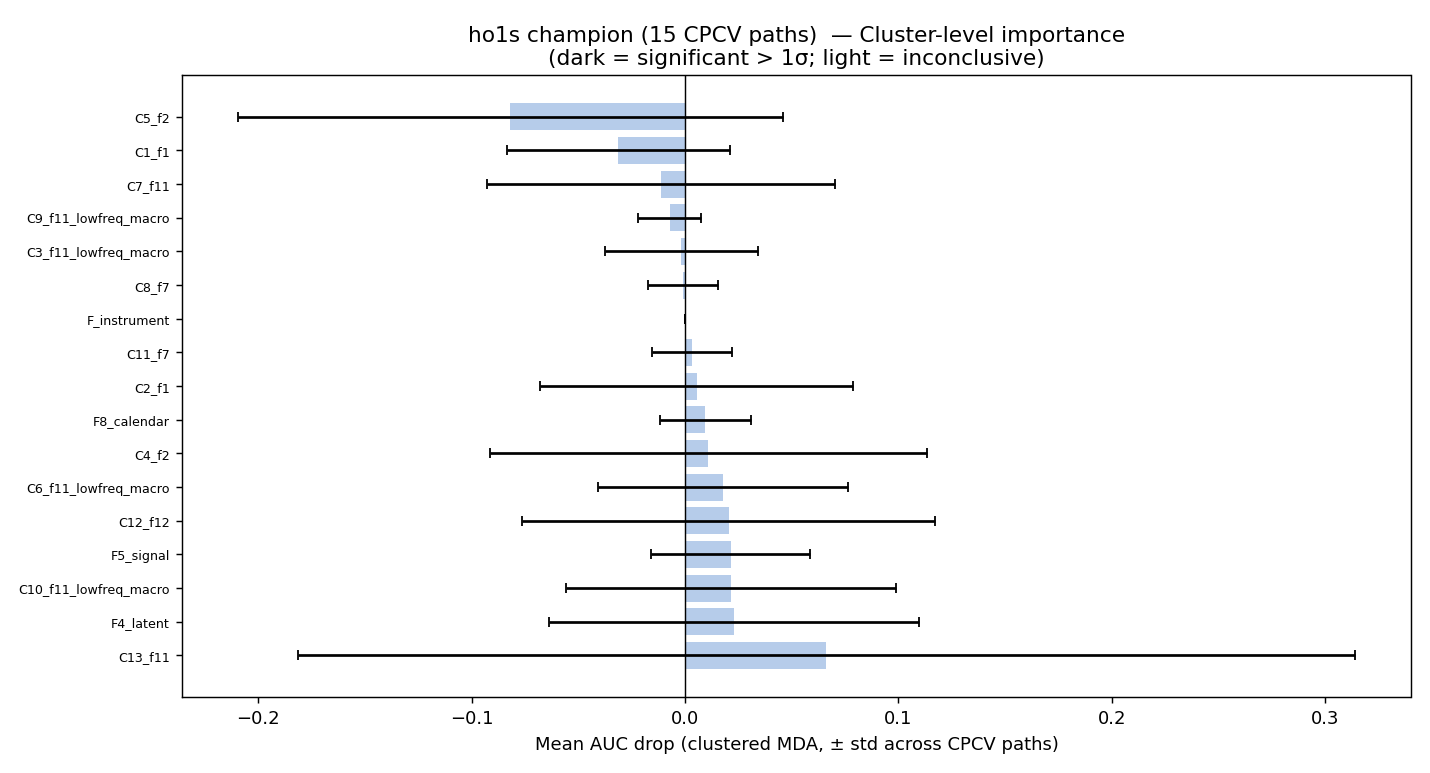

In [20]:
show(BASE / "ho1s" / "clustered_mda_chart.png", width=1050)


In [21]:
cc = load(BASE / "ho1s" / "cluster_crosscheck_table.csv")
ra = load(BASE / "ho1s" / "rank_agreement.csv")
if not cc.empty:
    display(
        cc.style
        .format({"mda_mean": "{:.4f}", "mdi_sum": "{:.4f}", "shap_sum": "{:.4f}"})
        .background_gradient(subset=["mda_mean"], cmap="RdYlGn", vmin=-0.05, vmax=0.15)
        .set_caption("ho1s — cluster cross-check table (MDA · MDI · SHAP ranks)")
    )
if not ra.empty:
    print("\nKendall τ rank agreement:")
    display(ra.style.format({"kendall_tau": "{:.2f}"}))


,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,C13_f11,0.0662,1,0.2212,1,0.0916,1,False
1,F4_latent,0.0230,2,0.0696,6,0.0217,7,False
2,C10_f11_lowfreq_macro,0.0215,3,0.0496,8,0.0209,8,False
3,F5_signal,0.0214,4,0.0366,10,0.0132,10,False
4,C12_f12,0.0205,5,0.1017,3,0.0373,3,False
5,C6_f11_lowfreq_macro,0.0179,6,0.0625,7,0.0232,6,False
6,C4_f2,0.0109,7,0.0798,5,0.0258,5,False
7,F8_calendar,0.0095,8,0.0127,14,0.0045,14,False
8,C2_f1,0.0055,9,0.1236,2,0.0497,2,False
9,C11_f7,0.0033,10,0.0178,13,0.0074,13,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.25,False
1,MDA-SHAP,0.24,False
2,MDI-SHAP,0.99,True


### 3 · Within-cluster breakdown (top clusters)

Members ranked by mean|SHAP|. Single-feature permutation is not used within a cluster
because correlated siblings underestimate importance — only the cluster-total MDA is
reliable. PCA checks whether the cluster is one latent dimension (high PC1 variance)
and which feature anchors it (PC1 loadings).


,feature,mean_shap_mag,pc1_loading
0,f11_gasoline_stock_surprise,0.0349,-0.339
1,f11_move_z,0.0139,-0.310
2,f11_ng_stock_surprise,0.0116,0.538
3,f11_baltic_5d_change,0.0077,0.252
4,f11_baltic_dry_z,0.0076,0.443
5,f1_bb_bandwidth_20,0.0069,-0.200
6,f6_adx_14,0.0049,-0.445
7,f13_path_tortuosity_20d,0.0032,0.019
8,hmm_macro_entropy,0.0008,-0.033
9,f7_oi_price_div_20,0.0002,-0.022


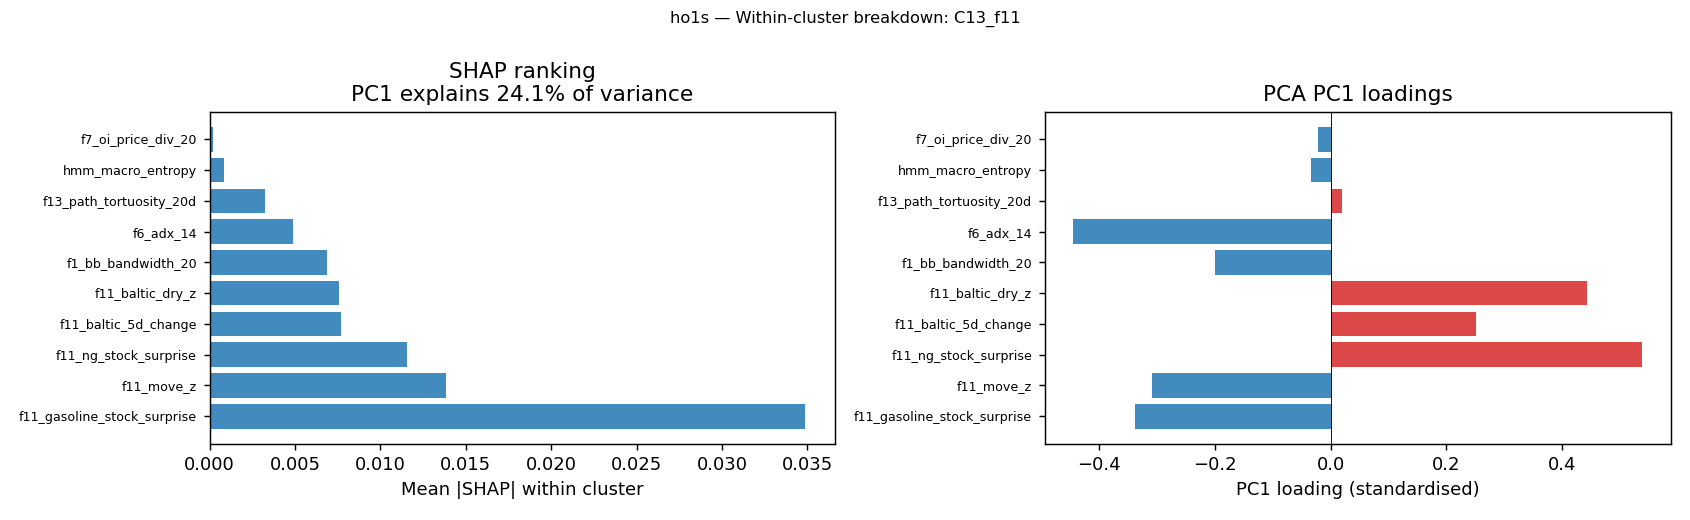

In [22]:
wc = load(BASE / "ho1s" / "within_cluster_C13_f11.csv")
if not wc.empty:
    pc1 = wc["pca_pc1_var_explained"].iloc[0]
    label = f"PC1 explains {pc1:.1%}" if pd.notna(pc1) else "PCA n/a"
    display(
        wc[["feature", "mean_shap_mag", "pc1_loading"]]
        .style
        .format({"mean_shap_mag": "{:.4f}", "pc1_loading": "{:.3f}"})
        .background_gradient(subset=["mean_shap_mag"], cmap="Blues")
        .set_caption(f"ho1s | C13_f11 — SHAP ranking + PC1 loadings  ({label})")
    )
show(BASE / "ho1s" / "within_cluster_C13_f11.png", width=1050)


,feature,mean_shap_mag,pc1_loading
0,f4_pc4,0.0092,0.388
1,f4_pc2,0.0076,0.573
2,f4_pc1,0.0025,-0.449
3,f4_pc3,0.0023,0.566


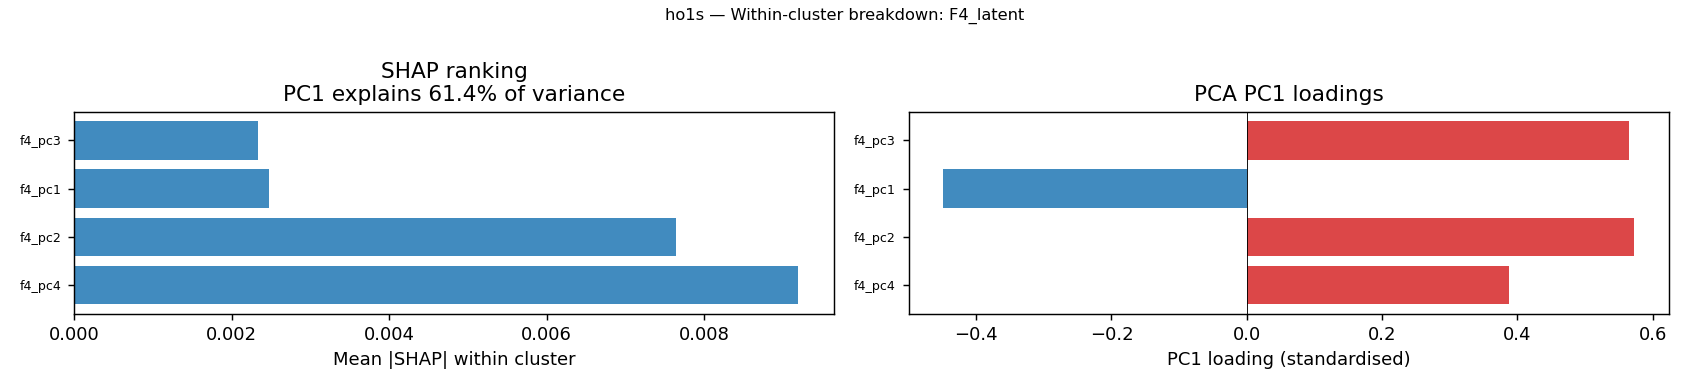

In [23]:
wc = load(BASE / "ho1s" / "within_cluster_F4_latent.csv")
if not wc.empty:
    pc1 = wc["pca_pc1_var_explained"].iloc[0]
    label = f"PC1 explains {pc1:.1%}" if pd.notna(pc1) else "PCA n/a"
    display(
        wc[["feature", "mean_shap_mag", "pc1_loading"]]
        .style
        .format({"mean_shap_mag": "{:.4f}", "pc1_loading": "{:.3f}"})
        .background_gradient(subset=["mean_shap_mag"], cmap="Blues")
        .set_caption(f"ho1s | F4_latent — SHAP ranking + PC1 loadings  ({label})")
    )
show(BASE / "ho1s" / "within_cluster_F4_latent.png", width=1050)


,feature,mean_shap_mag,pc1_loading
0,f11_vix_term_slope,0.0075,-0.380
1,f11_vix_level_z,0.0049,0.450
2,f11_ust_10y_5d_change,0.0035,-0.365
3,f11_bund_10y_5d_change,0.0020,-0.265
4,f11_hy_oas_5d_change,0.0012,0.354
5,f11_vix_5d_change,0.0010,0.435
6,f11_be_5d_change,0.0008,-0.367


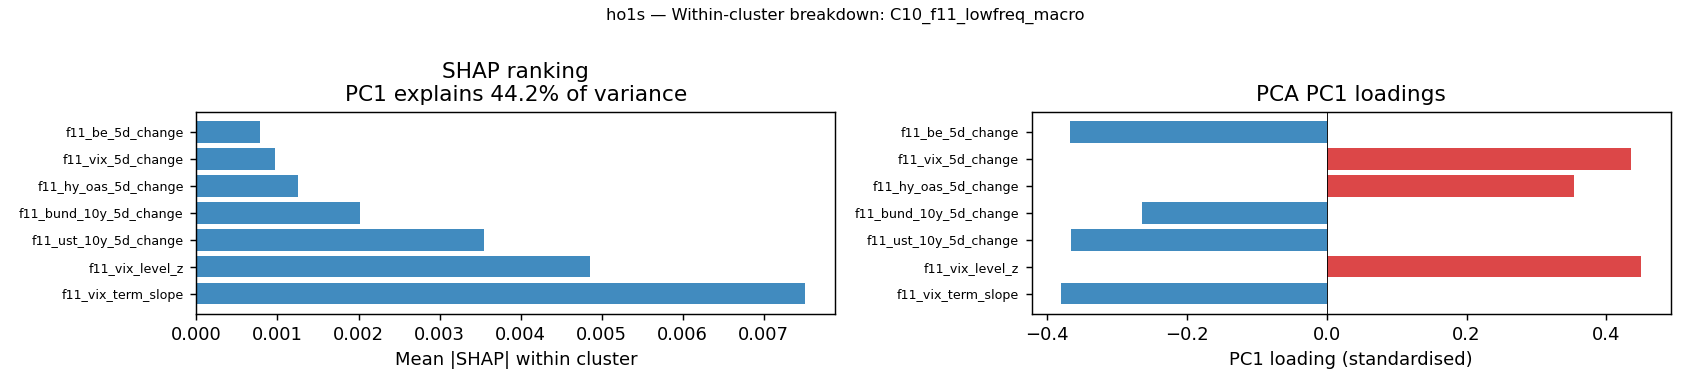

In [24]:
wc = load(BASE / "ho1s" / "within_cluster_C10_f11_lowfreq_macro.csv")
if not wc.empty:
    pc1 = wc["pca_pc1_var_explained"].iloc[0]
    label = f"PC1 explains {pc1:.1%}" if pd.notna(pc1) else "PCA n/a"
    display(
        wc[["feature", "mean_shap_mag", "pc1_loading"]]
        .style
        .format({"mean_shap_mag": "{:.4f}", "pc1_loading": "{:.3f}"})
        .background_gradient(subset=["mean_shap_mag"], cmap="Blues")
        .set_caption(f"ho1s | C10_f11_lowfreq_macro — SHAP ranking + PC1 loadings  ({label})")
    )
show(BASE / "ho1s" / "within_cluster_C10_f11_lowfreq_macro.png", width=1050)


### 4 · Global per-feature SHAP + MDI

Mean|SHAP| and signed SHAP per feature, averaged across CPCV paths on the target
instrument's test slice. MDI is the fold-averaged `feature_importances_` (sanity check).
Correlated siblings read low here individually — compare with the cluster-total MDA
above to see the correlation problem directly.


,feature,shap_magnitude,shap_signed,mdi
0,f11_gasoline_stock_surprise,0.0349,0.0149,0.0671
1,f11_move_z,0.0139,0.0045,0.0306
2,f11_move_vix_ratio,0.0124,-0.0009,0.0314
3,f11_ng_stock_surprise,0.0116,0.0016,0.0400
4,f2_vol_60,0.0107,-0.0013,0.0269
5,f11_real_yield_10y,0.0105,0.0018,0.0234
6,f6_ts_momentum_60,0.0102,0.0072,0.0189
7,f6_ma_cross_20_60,0.0096,0.0064,0.0184
8,f4_pc4,0.0092,-0.0026,0.0283
9,f11_baltic_5d_change,0.0077,0.0001,0.0225


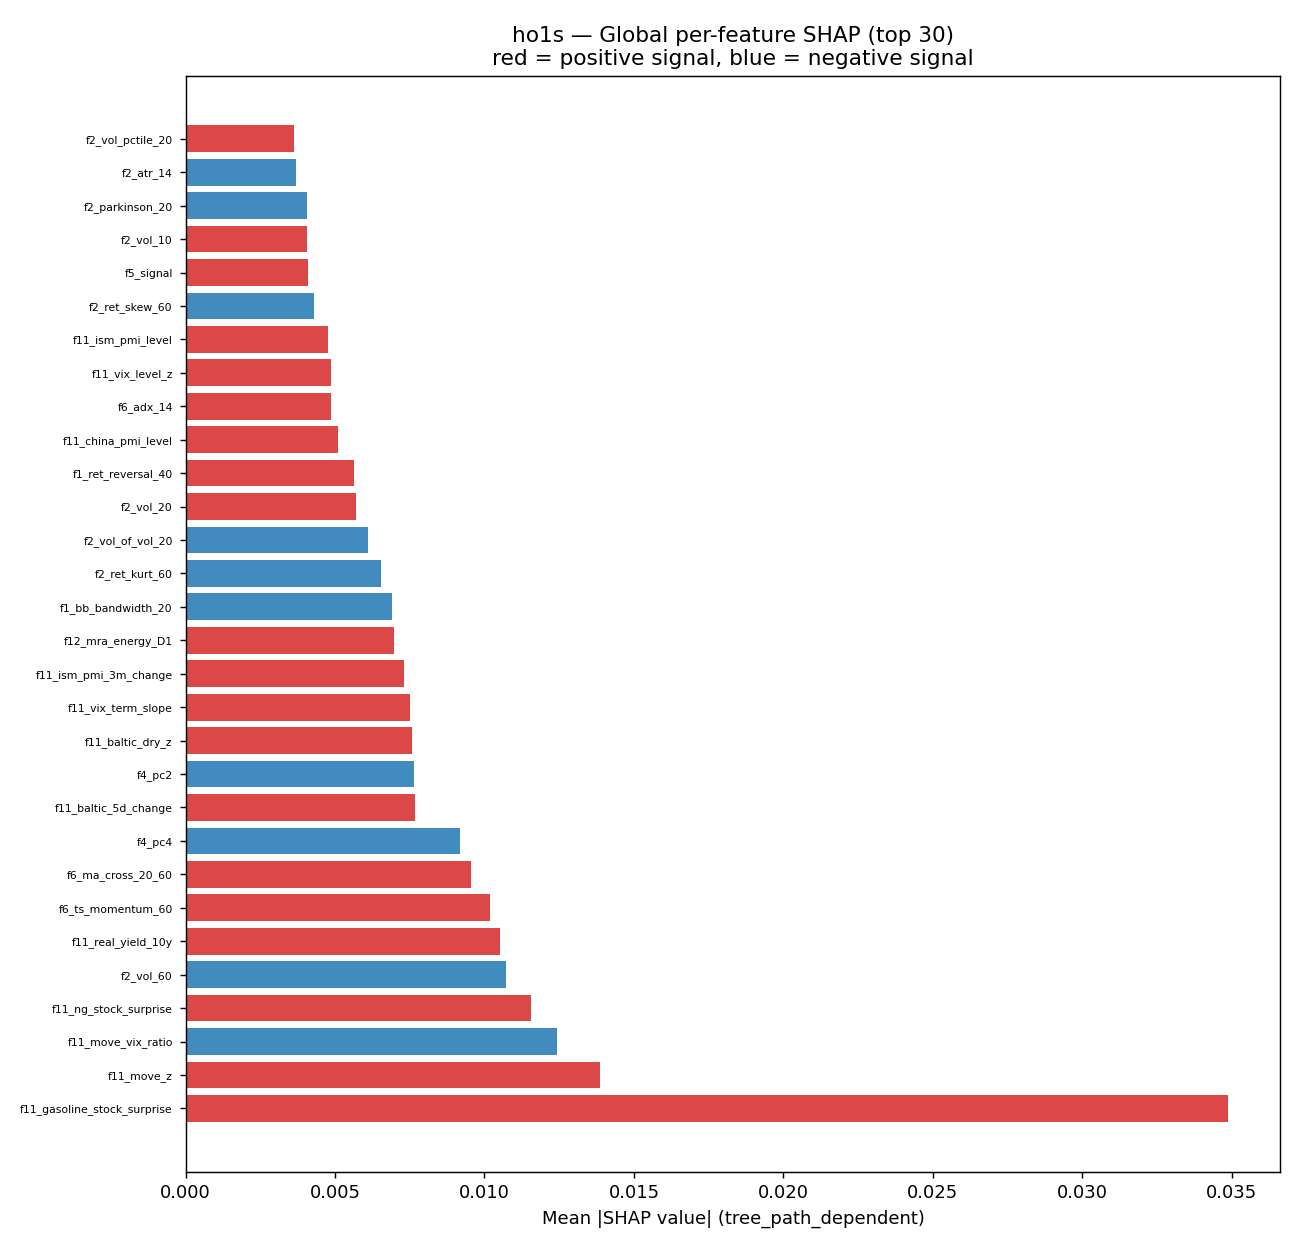

In [25]:
gs = load(BASE / "ho1s" / "global_shap_summary.csv")
if not gs.empty:
    display(
        gs.head(25).style
        .format({"shap_magnitude": "{:.4f}", "shap_signed": "{:.4f}", "mdi": "{:.4f}"})
        .background_gradient(subset=["shap_magnitude"], cmap="Blues")
        .set_caption("ho1s — top 25 features by mean|SHAP| (red=positive, blue=negative signal)")
    )
show(BASE / "ho1s" / "global_shap_chart.png", width=1000)


---
## RB1S — champion: `energy_all` / XGB

**CPCV:** 15 paths · AUC 0.629±0.121 · signal: *marginal*  
**Significant clusters (mean > 1σ):** `F5_signal`

RBOB Gasoline, scored from the `energy_all` pooled XGB on rb1s's test slice. Marginal signal. Only `F5_signal` is significant; all others inconclusive.


### 1 · Feature clusters

Features split into a **correlation-cluster block** (Ward linkage on √(1−|ρ|) Spearman
distance, K by silhouette) plus hand-assigned groups (F4 latent PCA, F5 signal-derived,
F8 calendar; F_instrument dummies for pooled models). Near-perfect pairs (|ρ| ≥ 0.99)
are deduplicated before clustering.

*Purity* = fraction of cluster members from the dominant F-prefix.
≥ 80% = the data-driven cluster recovered a semantic F-group.


In [26]:
# Cluster membership summary — rb1s
cs = cluster_summary("rb1s")
display(
    cs.style
    .format({"mean_drop": "{:.4f}", "std_drop": "{:.4f}", "purity": "{:.0%}"})
    .background_gradient(subset=["mean_drop"], cmap="RdYlGn", vmin=-0.05, vmax=0.15)
    .set_caption("rb1s — cluster summary (sorted by mean MDA drop)")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-weight","bold"),("font-size","12px")]}])
)


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
16,F5_signal,5,f5_,100%,0.1130,0.0821,True
1,C11_f11,6,f11_,67%,0.0292,0.0504,False
10,C5_f2,12,f2_,50%,0.0132,0.0328,False
14,C9_f11,5,f11_,80%,0.0098,0.0597,False
17,F8_calendar,4,f8_,100%,0.0032,0.0120,False
15,F4_latent,4,f4_,100%,0.0031,0.0077,False
4,C14_f11,5,f11_,80%,0.0016,0.0141,False
8,C3_f13,3,f13_,67%,0.0013,0.0042,False
3,C13_f11_lowfreq_macro,5,f11_,100%,0.0005,0.0119,False
11,C6_f7,2,f7_,100%,0.0002,0.0013,False


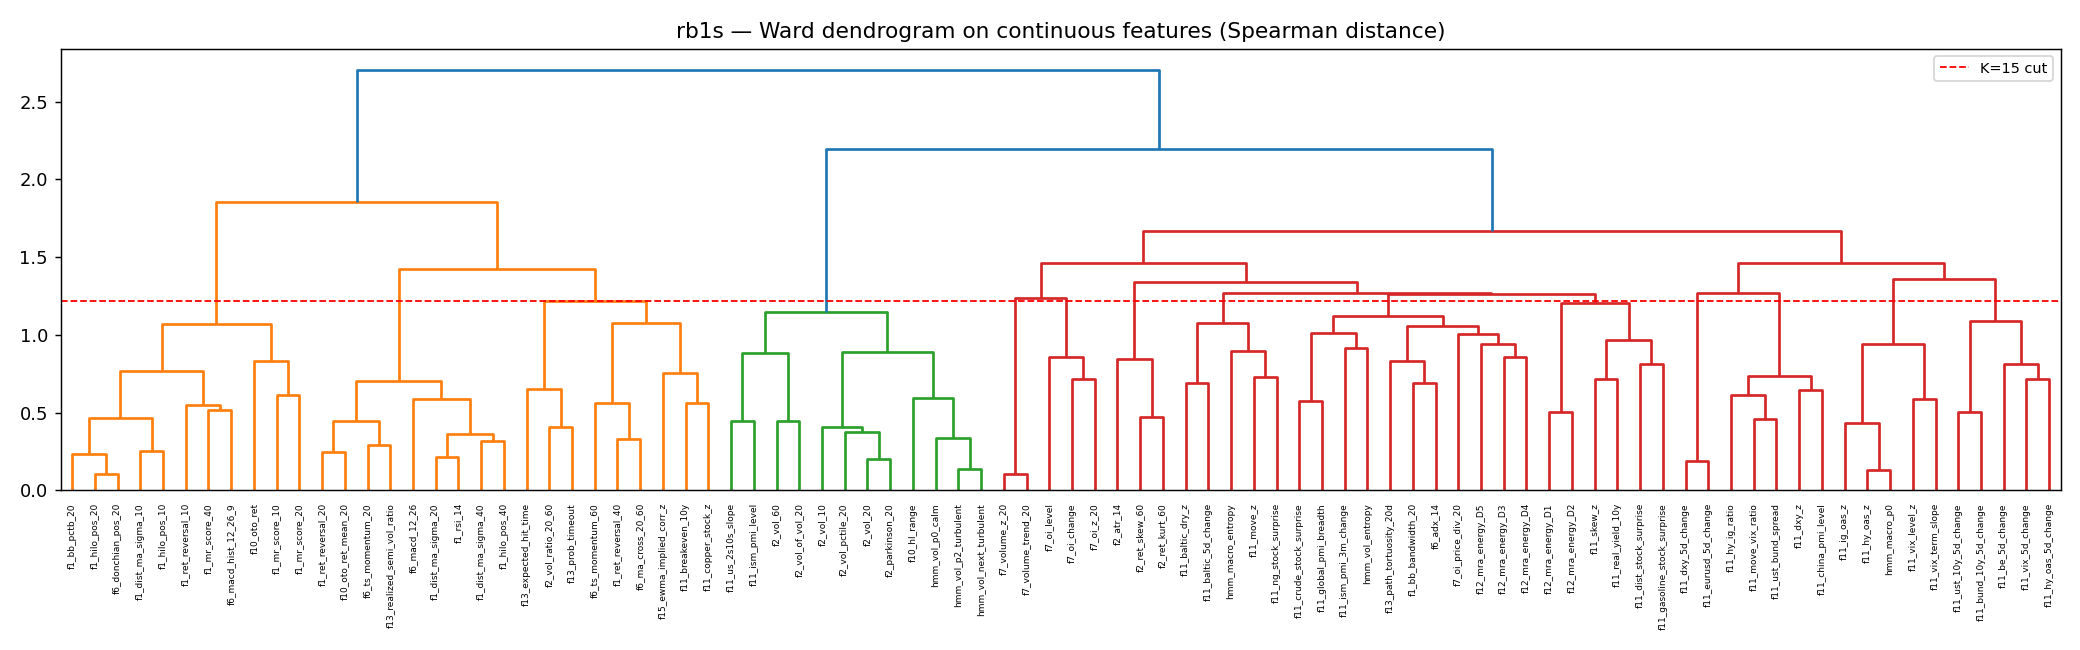

In [27]:
show(BASE / "rb1s" / "dendrogram.png", width=1100)


### 2 · Cluster-level importance

**Clustered MDA** (centerpiece): dark bars = significant (mean > 1σ from zero),
light = inconclusive. Error bars = ± std across CPCV paths.

**Cross-checks:** MDI sums `feature_importances_` per cluster (train-set, upward-biased).
Group SHAP sums mean|SHAP| per cluster (OOS, `tree_path_dependent`).
Kendall τ between cluster rankings flags whether the three methods agree.
MDI and SHAP typically agree strongly (intrinsic statistics); MDA is noisier (OOS test).


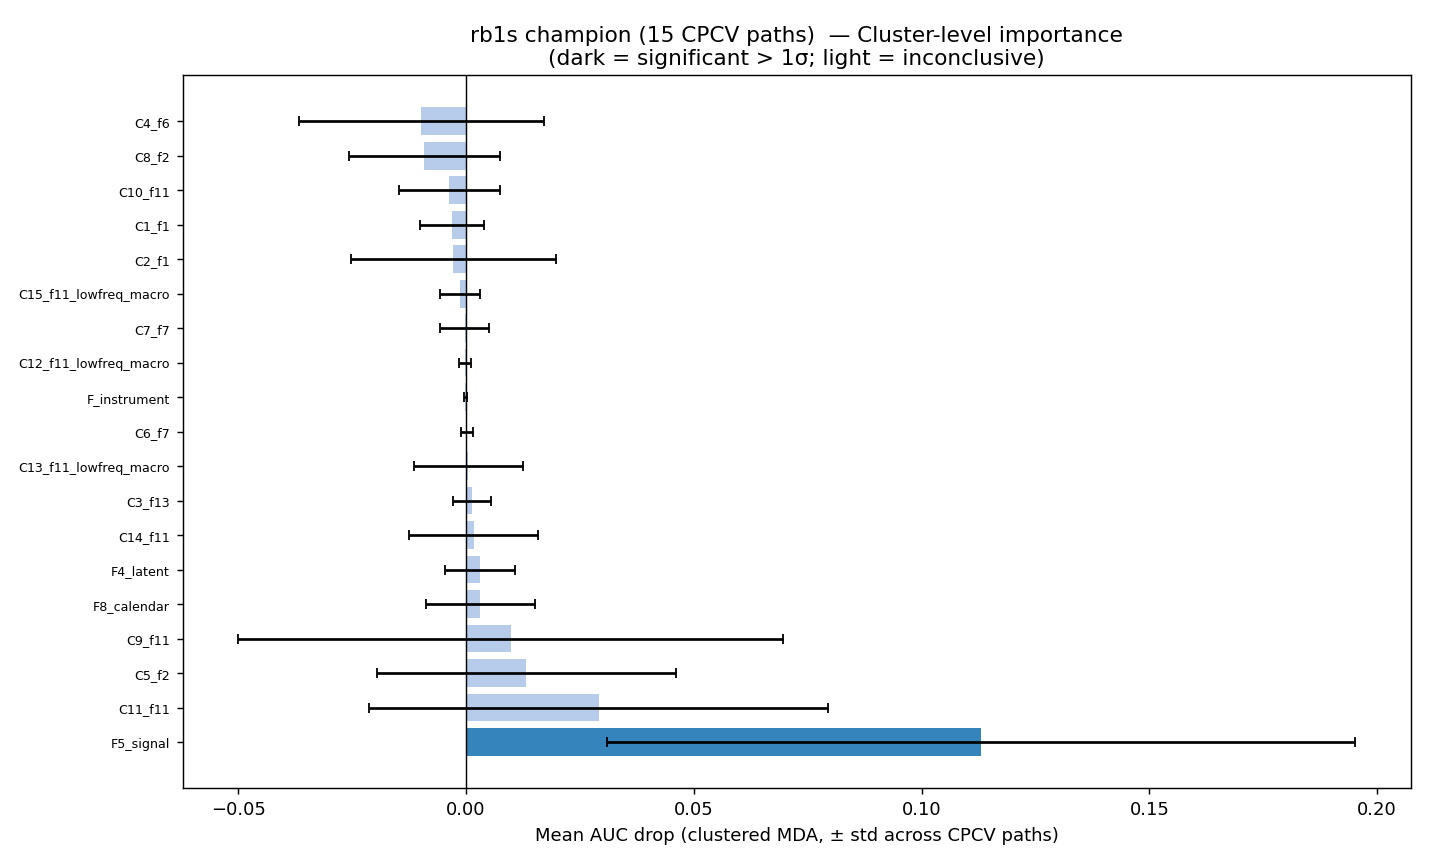

In [28]:
show(BASE / "rb1s" / "clustered_mda_chart.png", width=1050)


In [29]:
cc = load(BASE / "rb1s" / "cluster_crosscheck_table.csv")
ra = load(BASE / "rb1s" / "rank_agreement.csv")
if not cc.empty:
    display(
        cc.style
        .format({"mda_mean": "{:.4f}", "mdi_sum": "{:.4f}", "shap_sum": "{:.4f}"})
        .background_gradient(subset=["mda_mean"], cmap="RdYlGn", vmin=-0.05, vmax=0.15)
        .set_caption("rb1s — cluster cross-check table (MDA · MDI · SHAP ranks)")
    )
if not ra.empty:
    print("\nKendall τ rank agreement:")
    display(ra.style.format({"kendall_tau": "{:.2f}"}))


,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,F5_signal,0.1130,1,0.0795,5,0.2640,1,True
1,C11_f11,0.0292,2,0.0734,6,0.1187,4,False
2,C5_f2,0.0132,3,0.1351,1,0.2293,2,False
3,C9_f11,0.0098,4,0.0921,2,0.1856,3,False
4,F8_calendar,0.0032,5,0.0207,14,0.0093,16,False
5,F4_latent,0.0031,6,0.0450,12,0.0380,12,False
6,C14_f11,0.0016,7,0.0554,10,0.0682,6,False
7,C3_f13,0.0013,8,0.0203,16,0.0147,15,False
8,C13_f11_lowfreq_macro,0.0005,9,0.0600,9,0.0513,8,False
9,C6_f7,0.0002,10,0.0041,19,0.0028,18,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.08,False
1,MDA-SHAP,0.17,False
2,MDI-SHAP,0.77,True


### 3 · Within-cluster breakdown (top clusters)

Members ranked by mean|SHAP|. Single-feature permutation is not used within a cluster
because correlated siblings underestimate importance — only the cluster-total MDA is
reliable. PCA checks whether the cluster is one latent dimension (high PC1 variance)
and which feature anchors it (PC1 loadings).


,feature,mean_shap_mag,pc1_loading
0,f5_signal,0.2374,0.583
1,f5_long_bias_20,0.0144,0.620
2,f5_trailing_run_length,0.0090,0.423
3,f5_participation_20,0.0030,0.267
4,f5_sign_agree_mr,0.0002,-0.158


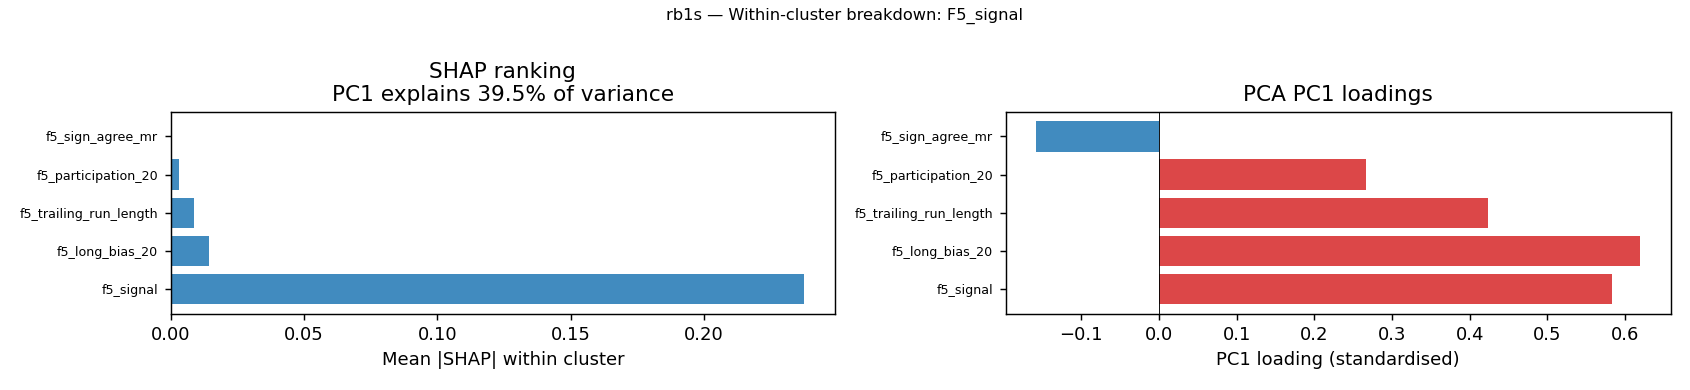

In [30]:
wc = load(BASE / "rb1s" / "within_cluster_F5_signal.csv")
if not wc.empty:
    pc1 = wc["pca_pc1_var_explained"].iloc[0]
    label = f"PC1 explains {pc1:.1%}" if pd.notna(pc1) else "PCA n/a"
    display(
        wc[["feature", "mean_shap_mag", "pc1_loading"]]
        .style
        .format({"mean_shap_mag": "{:.4f}", "pc1_loading": "{:.3f}"})
        .background_gradient(subset=["mean_shap_mag"], cmap="Blues")
        .set_caption(f"rb1s | F5_signal — SHAP ranking + PC1 loadings  ({label})")
    )
show(BASE / "rb1s" / "within_cluster_F5_signal.png", width=1050)


,feature,mean_shap_mag,pc1_loading
0,f11_gasoline_stock_surprise,0.0786,-0.104
1,f11_dist_stock_surprise,0.0160,0.260
2,f11_real_yield_10y,0.0138,-0.490
3,f11_skew_z,0.0075,0.315
4,f12_mra_energy_D1,0.0024,-0.496
5,f12_mra_energy_D2,0.0004,0.579


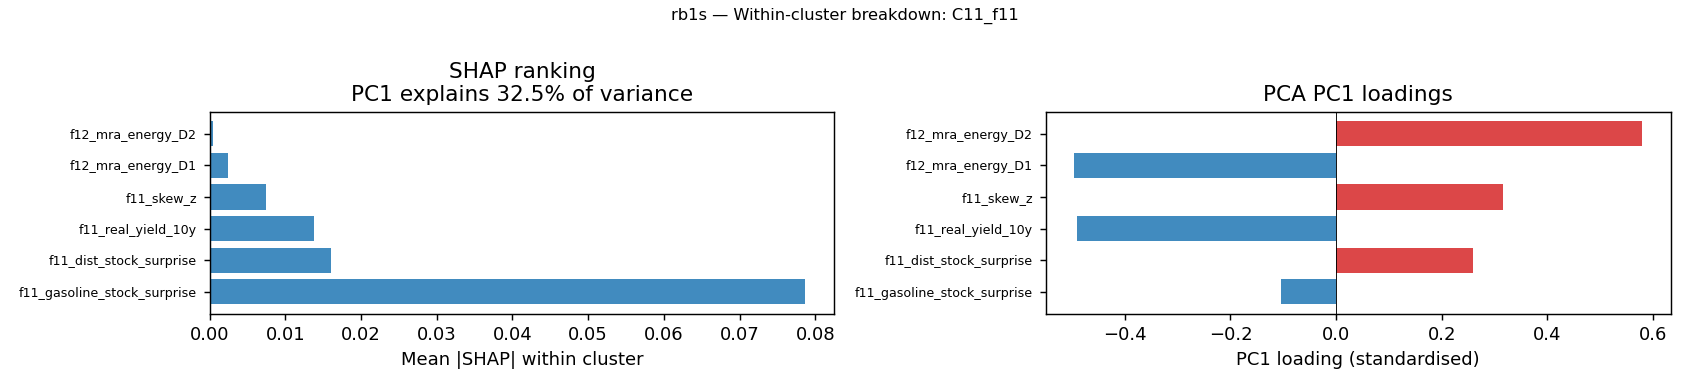

In [31]:
wc = load(BASE / "rb1s" / "within_cluster_C11_f11.csv")
if not wc.empty:
    pc1 = wc["pca_pc1_var_explained"].iloc[0]
    label = f"PC1 explains {pc1:.1%}" if pd.notna(pc1) else "PCA n/a"
    display(
        wc[["feature", "mean_shap_mag", "pc1_loading"]]
        .style
        .format({"mean_shap_mag": "{:.4f}", "pc1_loading": "{:.3f}"})
        .background_gradient(subset=["mean_shap_mag"], cmap="Blues")
        .set_caption(f"rb1s | C11_f11 — SHAP ranking + PC1 loadings  ({label})")
    )
show(BASE / "rb1s" / "within_cluster_C11_f11.png", width=1050)


,feature,mean_shap_mag,pc1_loading
0,f2_vol_60,0.1380,0.331
1,f2_vol_of_vol_20,0.0272,0.275
2,f11_us_2s10s_slope,0.0146,-0.211
3,f11_ism_pmi_level,0.0138,-0.276
4,f2_vol_10,0.0077,0.330
5,hmm_vol_next_turbulent,0.0070,0.304
6,hmm_vol_p0_calm,0.0061,-0.114
7,f2_parkinson_20,0.0051,0.344
8,f2_vol_20,0.0033,0.351
9,f10_hl_range,0.0032,0.256


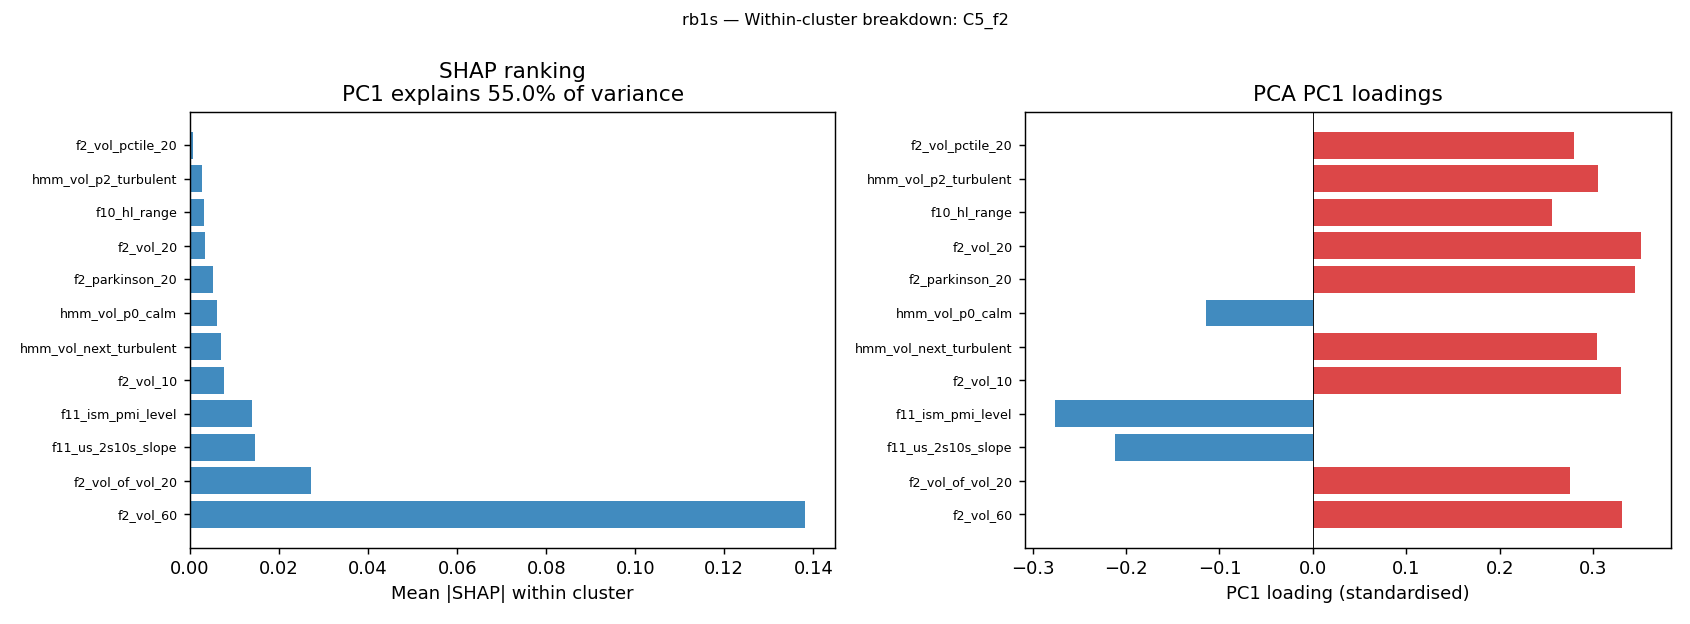

In [32]:
wc = load(BASE / "rb1s" / "within_cluster_C5_f2.csv")
if not wc.empty:
    pc1 = wc["pca_pc1_var_explained"].iloc[0]
    label = f"PC1 explains {pc1:.1%}" if pd.notna(pc1) else "PCA n/a"
    display(
        wc[["feature", "mean_shap_mag", "pc1_loading"]]
        .style
        .format({"mean_shap_mag": "{:.4f}", "pc1_loading": "{:.3f}"})
        .background_gradient(subset=["mean_shap_mag"], cmap="Blues")
        .set_caption(f"rb1s | C5_f2 — SHAP ranking + PC1 loadings  ({label})")
    )
show(BASE / "rb1s" / "within_cluster_C5_f2.png", width=1050)


### 4 · Global per-feature SHAP + MDI

Mean|SHAP| and signed SHAP per feature, averaged across CPCV paths on the target
instrument's test slice. MDI is the fold-averaged `feature_importances_` (sanity check).
Correlated siblings read low here individually — compare with the cluster-total MDA
above to see the correlation problem directly.


,feature,shap_magnitude,shap_signed,mdi
0,f5_signal,0.2374,0.0119,0.0434
1,f2_vol_60,0.1380,0.0378,0.0285
2,f11_move_z,0.1003,-0.0326,0.0263
3,f11_gasoline_stock_surprise,0.0786,0.0064,0.0324
4,f11_ng_stock_surprise,0.0380,-0.0029,0.0253
5,f11_breakeven_10y,0.0352,0.0179,0.0121
6,f15_ewma_implied_corr_z,0.0302,0.0020,0.0162
7,f2_vol_of_vol_20,0.0272,-0.0106,0.0175
8,f11_baltic_dry_z,0.0264,-0.0031,0.0143
9,f7_oi_level,0.0259,-0.0248,0.0120


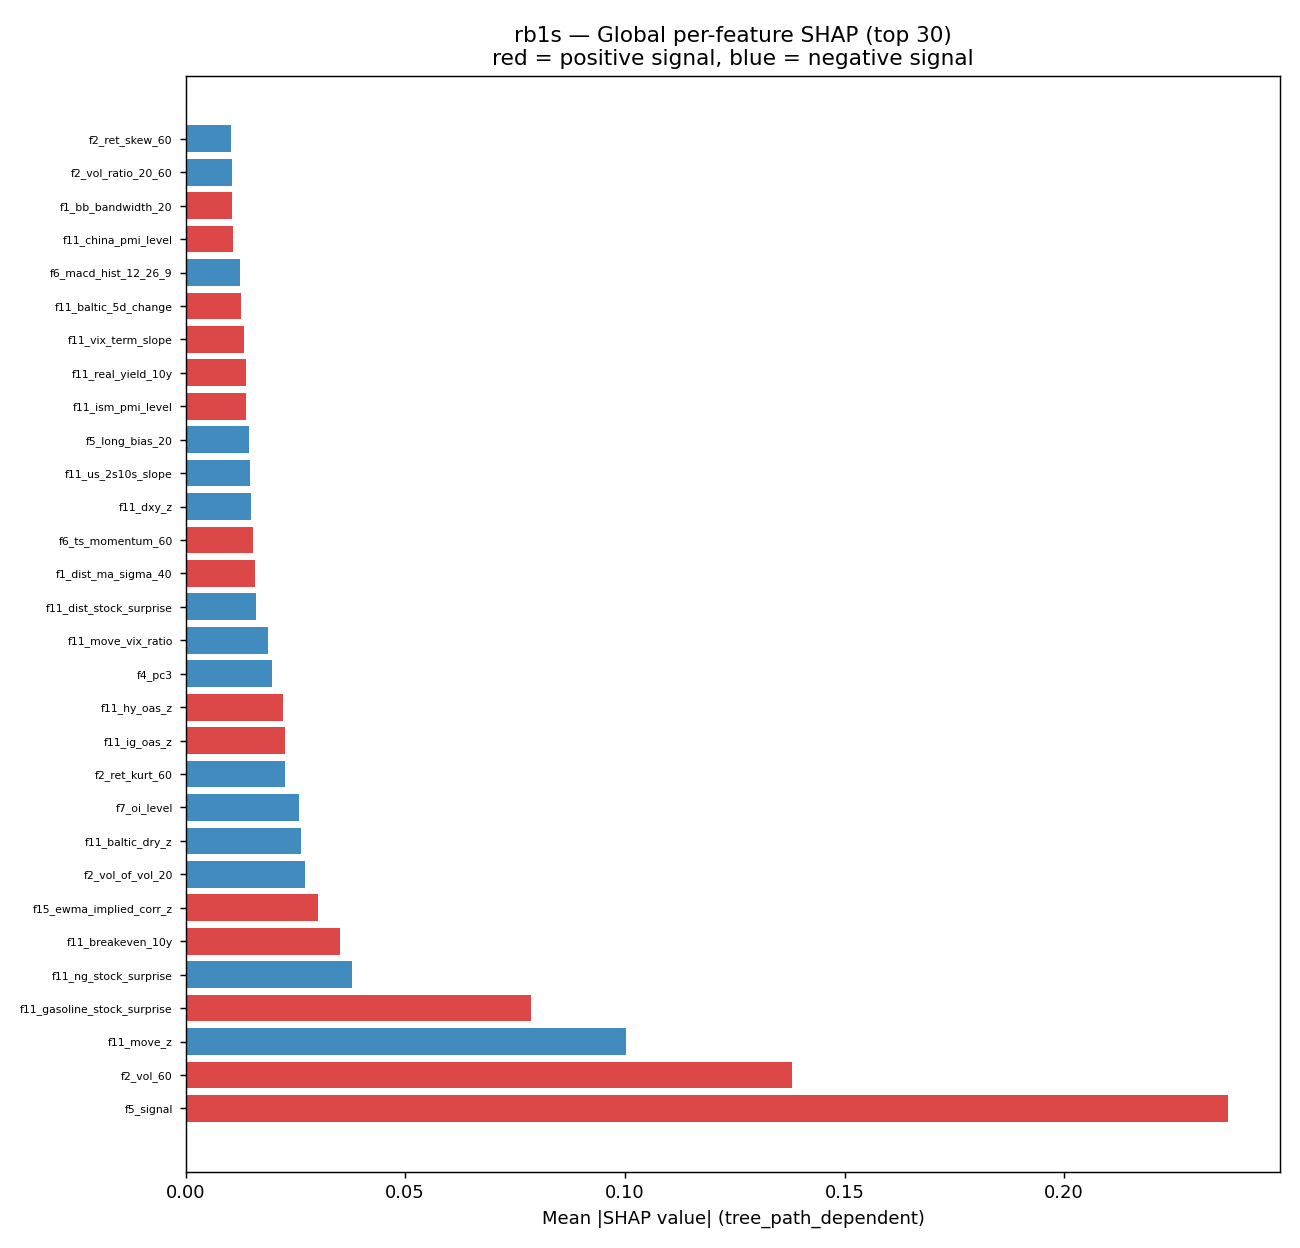

In [33]:
gs = load(BASE / "rb1s" / "global_shap_summary.csv")
if not gs.empty:
    display(
        gs.head(25).style
        .format({"shap_magnitude": "{:.4f}", "shap_signed": "{:.4f}", "mdi": "{:.4f}"})
        .background_gradient(subset=["shap_magnitude"], cmap="Blues")
        .set_caption("rb1s — top 25 features by mean|SHAP| (red=positive, blue=negative signal)")
    )
show(BASE / "rb1s" / "global_shap_chart.png", width=1000)


---
## Cross-instrument findings

Structured summary across all four champions.


In [34]:
# Cross-instrument: top cluster + rank agreement
rows = []
for inst in ["cl1s", "es1s", "ho1s", "rb1s"]:
    mda = load(BASE / inst / "clustered_mda_full.csv")
    ra  = load(BASE / inst / "rank_agreement.csv")
    if mda.empty:
        continue
    top = mda.sort_values("mean_drop", ascending=False).iloc[0]
    sig_n = int(mda["significant"].sum()) if "significant" in mda.columns else 0

    def get_tau(pair):
        if ra.empty or "method_pair" not in ra.columns:
            return float("nan")
        m = ra[ra["method_pair"] == pair]
        return float(m["kendall_tau"].values[0]) if len(m) else float("nan")

    rows.append({
        "instrument":    inst,
        "n_sig_clusters": sig_n,
        "top_cluster":   top["cluster"],
        "top_mda":       top["mean_drop"],
        "top_std":       top["std_drop"],
        "τ MDA-SHAP":    get_tau("MDA-SHAP"),
        "τ MDI-SHAP":    get_tau("MDI-SHAP"),
    })

summary = pd.DataFrame(rows)
display(
    summary.style
    .format({"top_mda": "{:.4f}", "top_std": "{:.4f}",
             "τ MDA-SHAP": "{:.2f}", "τ MDI-SHAP": "{:.2f}"})
    .background_gradient(subset=["top_mda"], cmap="RdYlGn", vmin=0, vmax=0.15)
    .set_caption("Cross-instrument summary: top driving cluster and Kendall τ rank agreement")
)


,instrument,n_sig_clusters,top_cluster,top_mda,top_std,τ MDA-SHAP,τ MDI-SHAP
0,cl1s,2,C4_f2,0.1332,0.1221,0.25,0.80
1,es1s,1,F5_signal,0.0752,0.0374,0.18,0.94
2,ho1s,0,C13_f11,0.0662,0.2475,0.24,0.99
3,rb1s,1,F5_signal,0.1130,0.0821,0.17,0.77


In [35]:
# Semantic F-group recovery across instruments
rows = []
for inst in ["cl1s", "es1s", "ho1s", "rb1s"]:
    mem = load(BASE / inst / "cluster_membership.csv")
    if mem.empty:
        continue
    grp = (
        mem.groupby("cluster")
        .agg(purity=("f_prefix", lambda x: x.value_counts().iloc[0] / len(x)))
        .reset_index()
    )
    n_total = len(grp)
    n_pure  = (grp["purity"] >= 0.80).sum()
    rows.append({
        "instrument":    inst,
        "n_clusters":    n_total,
        "n_pure (≥80%)": n_pure,
        "n_mixed":       n_total - n_pure,
        "pct_pure":      f"{n_pure / n_total:.0%}",
    })

rec = pd.DataFrame(rows)
display(
    rec.set_index("instrument").style
    .set_caption("Semantic recovery: pure = ≥80% members from one F-prefix")
)


,n_clusters,n_pure (≥80%),n_mixed,pct_pure
instrument,,,,
cl1s,18,10,8,56%
es1s,15,6,9,40%
ho1s,17,11,6,65%
rb1s,19,12,7,63%


### Key observations

**Driving clusters:**
- **cl1s** (strong): `C4_f2` (volatility/dispersion, +0.133 ± 0.122) dominates; `C12_f11`
  (mixed macro, +0.085 ± 0.074) is second. Both significant — cl1s returns have a
  clear regime-volatility and macro component that the XGB exploits.
- **es1s** (marginal): only `F5_signal` (signal-derived features, +0.075 ± 0.037)
  is significant. Within F5, `f5_trailing_run_length` leads by SHAP — the RF latches
  onto signal persistence rather than any price or macro predictor.
- **ho1s** (strong but thin): no cluster clears 1σ. `C13_f11` leads in mean drop (0.066)
  but std (0.247) swamps it. EIA inventory and Baltic Dry features are the top SHAP members.
  Interpret as directionally consistent with cl1s, not as a standalone finding.
- **rb1s** (marginal): `F5_signal` dominates (+0.113 ± 0.082), anchored by `f5_signal`
  itself (mean|SHAP|=0.237). The XGB on the pooled energy set relies almost entirely
  on signal-derived features for rb1s — macro and price clusters are inconclusive.

**Method agreement:**
MDI and SHAP agree strongly (τ ≈ 0.77–0.99) — both are model-intrinsic and low-variance.
MDA disagrees with both (τ ≈ 0.08–0.35) because it is an OOS test-set statistic and
noisier, especially on marginal instruments. The highest-MDA cluster is consistent
across all three methods in every instrument — the disagreement lives in the tail.

**Semantic recovery:**
Hand-assigned groups (F4, F5, F8, F_instrument) are pure by construction.
In the correlation-cluster block, F7 and F12 clusters are often pure;
F11 macro features split across several mixed clusters because they
co-move by update cadence as much as by economic meaning.

**Signal caveats:**
- cl1s: interpret importance directly.
- es1s, rb1s: marginal — broad-brush conclusions only; don't rank individual clusters.
- ho1s: treat all importance as indicative; high path std makes individual cluster
  estimates unreliable.
